STARTED:      1/16/25

LAST UPDATED: 3/31/25

By Eugene Fong

# GOAL(S)

- EDA on the SN data

# IMPORTS

In [1]:
import numpy as np
import os
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import pprint
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context

/data/fonge2/conda/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/data/fonge2/conda/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/data/fonge2/conda/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/data/fonge2/conda/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/data/fonge2/conda/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.


# LOAD DATA

Actual source:
```
data_dir = '/data/CARD_singlecell/Brain_atlas/SN_Multiome/'

data_dir+'batch{batch}/Multiome/{sample}-ARC/outs/01_{sample}_anndata_object_atac.h5ad', 
```

SN controls table:
```
/vf/users/CARD_singlecell/SN_control_atlas/input/SN_control_samples.csv
```

In [2]:
# # DEFINE FILE PATHS - CHANGE THIS!!!
input_file = '/vf/users/CARD_singlecell/SN_control_atlas/multiome-pipeline/input/SN_control_samples.csv'
# input_file = os.path.join('..', 'input', 'SN_control_samples.csv')

# CHECK
print('input_file =', input_file)

input_file = /vf/users/CARD_singlecell/SN_control_atlas/multiome-pipeline/input/SN_control_samples.csv


In [3]:
# LOAD - matrix file into a Pandas DF
df = pd.read_csv(input_file) 
df

,Unnamed: 0.1,Unnamed: 0,Sample_ID,Homogenizing_batch,Library_batch,Sequencing_batch,Repeated,Use_batch,Age,PMI,Ethnicity,Race,Brain_bank,Short Diagnosis,Sample,Sex
0,0,0,890,1,1,0,0,0,18.2,36.50,Not Hispanic or Latino,Black or African-American,HBCC,Control,890,Male
1,1,1,885,1,1,0,0,0,19.9,21.50,Not Hispanic or Latino,Black or African-American,HBCC,Control,885,Male
2,2,2,1331,15,12,2,0,2,20.2,33.50,Hispanic or Latino,NaN,HBCC,Control,1331,Male
3,3,3,1187,4,4,0,1,0,21.5,25.00,Not Hispanic or Latino,Black or African-American,HBCC,Control,1187,Female
4,4,4,1306,13,11,2,0,2,21.5,15.00,Not Hispanic or Latino,Black or African-American,HBCC,Control,1306,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,114,115,PT13449,36,24,6,0,6,75.0,21.90,NaN,White,Pittsburgh,Control,PT13449,Male
115,115,116,PT13818,36,24,6,0,6,67.0,10.87,NaN,Black or African-American,Pittsburgh,Control,PT13818,Male
116,238,239,SP5568,40,27,7,0,7,65.0,22.40,NaN,Black or African-American,Sepulveda,Control,SP5568,Female
117,239,240,SP5777,40,27,7,0,7,79.0,12.30,NaN,Asian,Sepulveda,Control,SP5777,Female


In [4]:
# DROP - the first 2 columns
df = df.drop(df.columns[:2], axis=1)
df

,Sample_ID,Homogenizing_batch,Library_batch,Sequencing_batch,Repeated,Use_batch,Age,PMI,Ethnicity,Race,Brain_bank,Short Diagnosis,Sample,Sex
0,890,1,1,0,0,0,18.2,36.50,Not Hispanic or Latino,Black or African-American,HBCC,Control,890,Male
1,885,1,1,0,0,0,19.9,21.50,Not Hispanic or Latino,Black or African-American,HBCC,Control,885,Male
2,1331,15,12,2,0,2,20.2,33.50,Hispanic or Latino,NaN,HBCC,Control,1331,Male
3,1187,4,4,0,1,0,21.5,25.00,Not Hispanic or Latino,Black or African-American,HBCC,Control,1187,Female
4,1306,13,11,2,0,2,21.5,15.00,Not Hispanic or Latino,Black or African-American,HBCC,Control,1306,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,PT13449,36,24,6,0,6,75.0,21.90,NaN,White,Pittsburgh,Control,PT13449,Male
115,PT13818,36,24,6,0,6,67.0,10.87,NaN,Black or African-American,Pittsburgh,Control,PT13818,Male
116,SP5568,40,27,7,0,7,65.0,22.40,NaN,Black or African-American,Sepulveda,Control,SP5568,Female
117,SP5777,40,27,7,0,7,79.0,12.30,NaN,Asian,Sepulveda,Control,SP5777,Female


### FIX - typo

In [5]:
print(df['Brain_bank'].unique())

['HBCC' 'Mount Sinai NBTR' 'Human Brain and Spinal Fluid Resource Center'
 'Miami' 'Harvard' 'Havard' 'Pittsburgh' 'Sepulveda']


In [6]:
# CHECK - how many typos?
len(df[df['Brain_bank'] == 'Havard'])

1

In [7]:
# Replace the wrong spelling
df['Brain_bank'] = df['Brain_bank'].str.replace('Havard', 'Harvard')

# CHECK
len(df[df['Brain_bank'] == 'Havard'])

0

In [8]:
# CHANGE - name, just too long to fit on graphs

# Add a next line 
df['Brain_bank'] = df['Brain_bank'].str.replace('Human Brain and Spinal Fluid Resource Center', 'Human Brain and Spinal \nFluid Resource Center')

# CHECK
print(df['Brain_bank'].unique())

['HBCC' 'Mount Sinai NBTR'
 'Human Brain and Spinal \nFluid Resource Center' 'Miami' 'Harvard'
 'Pittsburgh' 'Sepulveda']


### METADATA

# #? Q) Is there a data dictionary somewhere?


In [9]:
print(f'Shape of DF: \n{df.shape[0]} rows X {df.shape[1]} columns')

Shape of DF: 
119 rows X 14 columns


In [10]:
df.describe()

,Homogenizing_batch,Library_batch,Sequencing_batch,Repeated,Use_batch,Age,PMI
count,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,118.000000
mean,13.109244,10.243697,1.823529,0.109244,1.857143,54.705042,28.577627
std,8.824840,5.731220,1.660340,0.313264,1.698882,19.161503,15.640584
min,1.000000,1.000000,0.000000,0.000000,0.000000,18.200000,4.000000
25%,7.000000,7.000000,1.000000,0.000000,1.000000,40.050000,15.700000
50%,12.000000,10.000000,2.000000,0.000000,2.000000,57.900000,25.815000
75%,17.000000,13.000000,2.500000,0.000000,2.500000,66.550000,37.750000
max,40.000000,27.000000,7.000000,1.000000,7.000000,97.000000,89.500000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Sample_ID           119 non-null    object 
 1   Homogenizing_batch  119 non-null    int64  
 2   Library_batch       119 non-null    int64  
 3   Sequencing_batch    119 non-null    int64  
 4   Repeated            119 non-null    int64  
 5   Use_batch           119 non-null    int64  
 6   Age                 119 non-null    float64
 7   PMI                 118 non-null    float64
 8   Ethnicity           95 non-null     object 
 9   Race                113 non-null    object 
 10  Brain_bank          119 non-null    object 
 11  Short Diagnosis     119 non-null    object 
 12  Sample              119 non-null    object 
 13  Sex                 119 non-null    object 
dtypes: float64(2), int64(5), object(7)
memory usage: 13.1+ KB


In [12]:
df.drop_duplicates()
for column in df.columns:
    unique_values = df[column].unique()
    print(f'Unique values in {column}: \n{unique_values}\n')

Unique values in Sample_ID: 
['890' '885' '1331' '1187' '1306' '852' '1908' '1276' '845' '2636' '1657'
 '1604' '2790' '1745' '3147' '1410' '2860' '993' '1405' '1571' '3192'
 '2420' '1898' '1385' '2429' '2943' '1357' '1884' '2781' '2303' '2064'
 '2263' '1390' '1105' '2046' '2074' '1883' '1644' '1179' '1905' '1525'
 '1691' '2552' '1560' '1722' '2453' '2267' '1927' '2543' '2587' '2287'
 '1424' '1431' '859' '1611' '2513' '1832' '2076' '2605' '2304' '894'
 '2927' '1285' '2575' '2703' '51502' '4276' 'HCTZS' '1135' '2454' '1275'
 '55015' '1537' '1654' '1297' '1023' '33987' '6119' '2322' '638682' '1494'
 '2689' '5931' 'BEB21104' '2053' '6038' '2936' 'BEB19019' '6178' '1615'
 '458379' '31556' '2003' '5695' 'S14752' '1613' '3284' '5967' '5769'
 'S15709' '43750' '45135' '2026' '3698' '2539' '831' 'S05135' '3857'
 'HCTZZV' '6118' '6087' 'BEB20008' 'PT13122' 'PT13440' 'PT13449' 'PT13818'
 'SP5568' 'SP5777' 'SP5256']

Unique values in Homogenizing_batch: 
[ 1 15  4 13  9 18 10 14 12 16 11 17  8  2  

### PLOTTING

CHECK - for missing data 1st

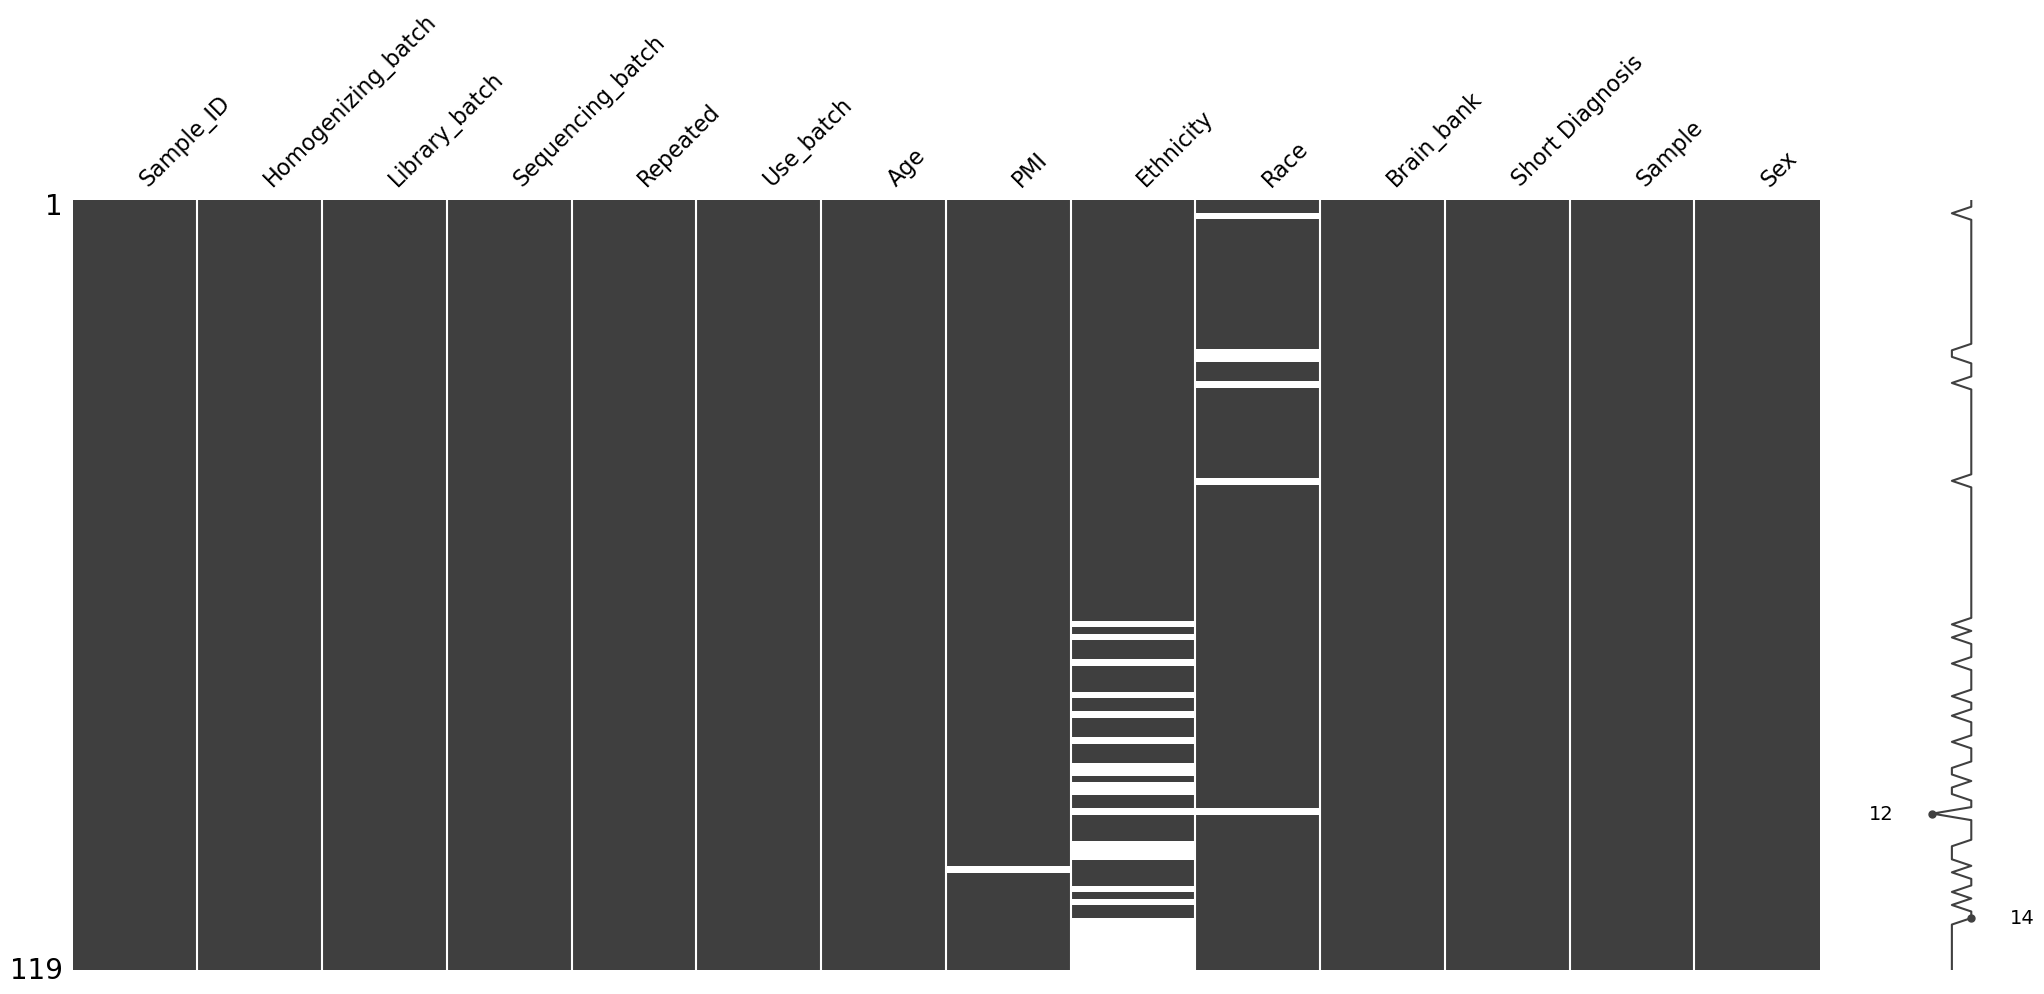

In [13]:
# PLOT - missing data using missingno
msno.matrix(df)
plt.show()

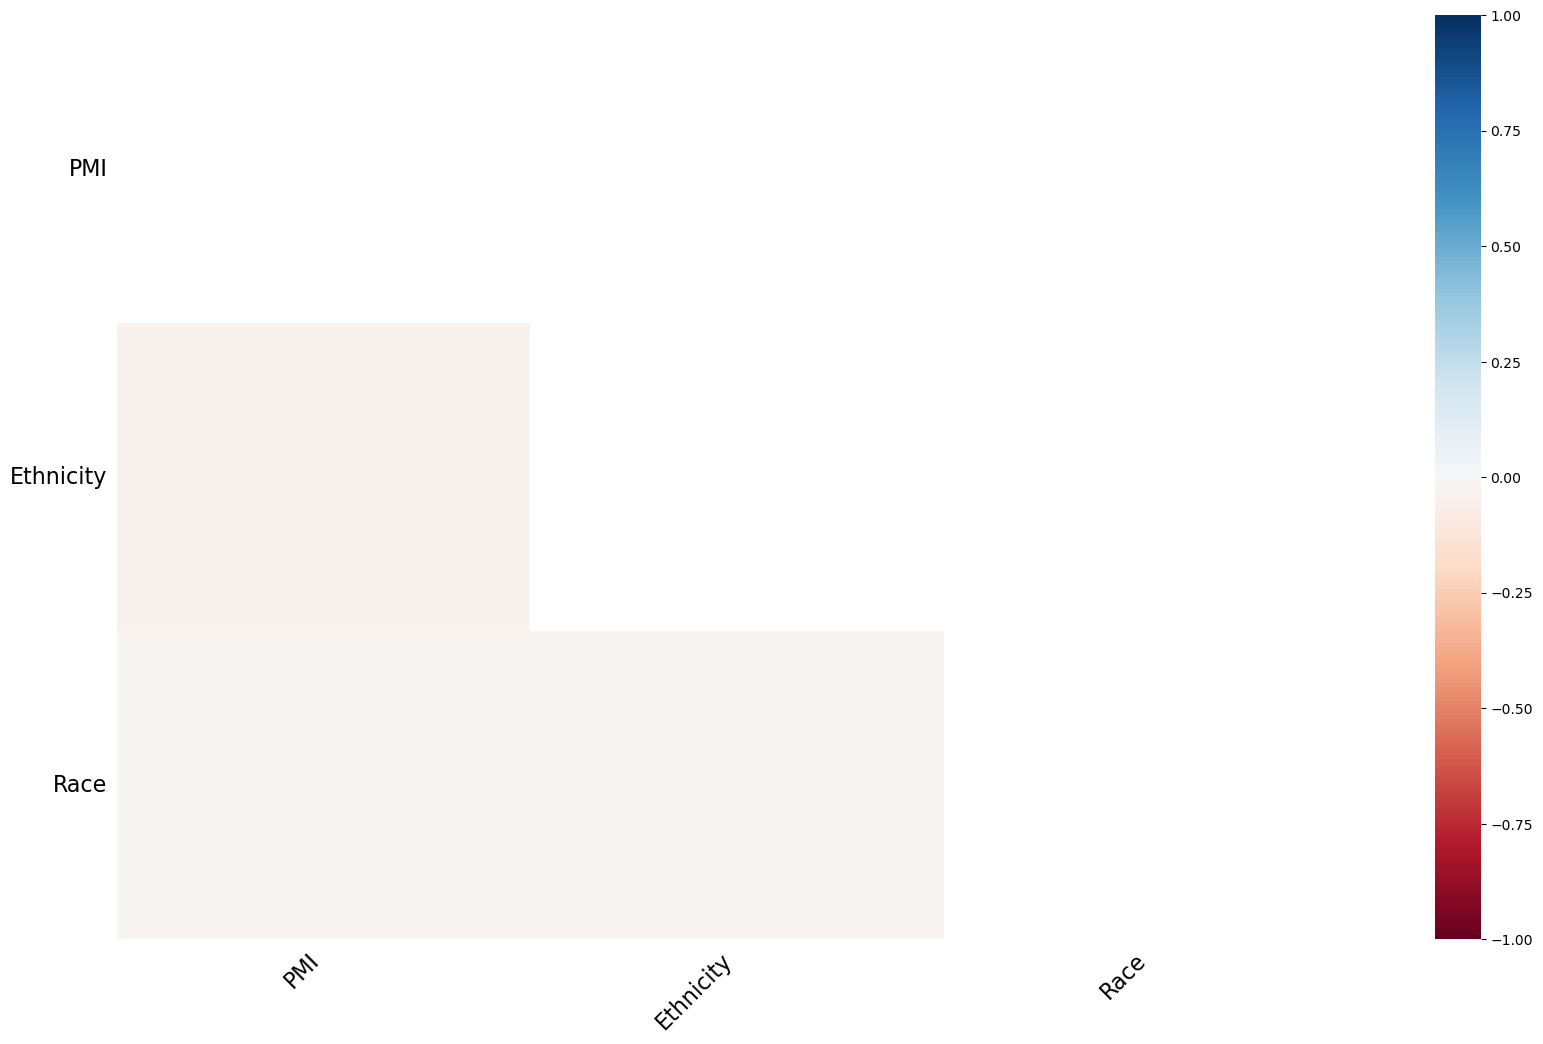

In [14]:
msno.heatmap(df)
plt.show()

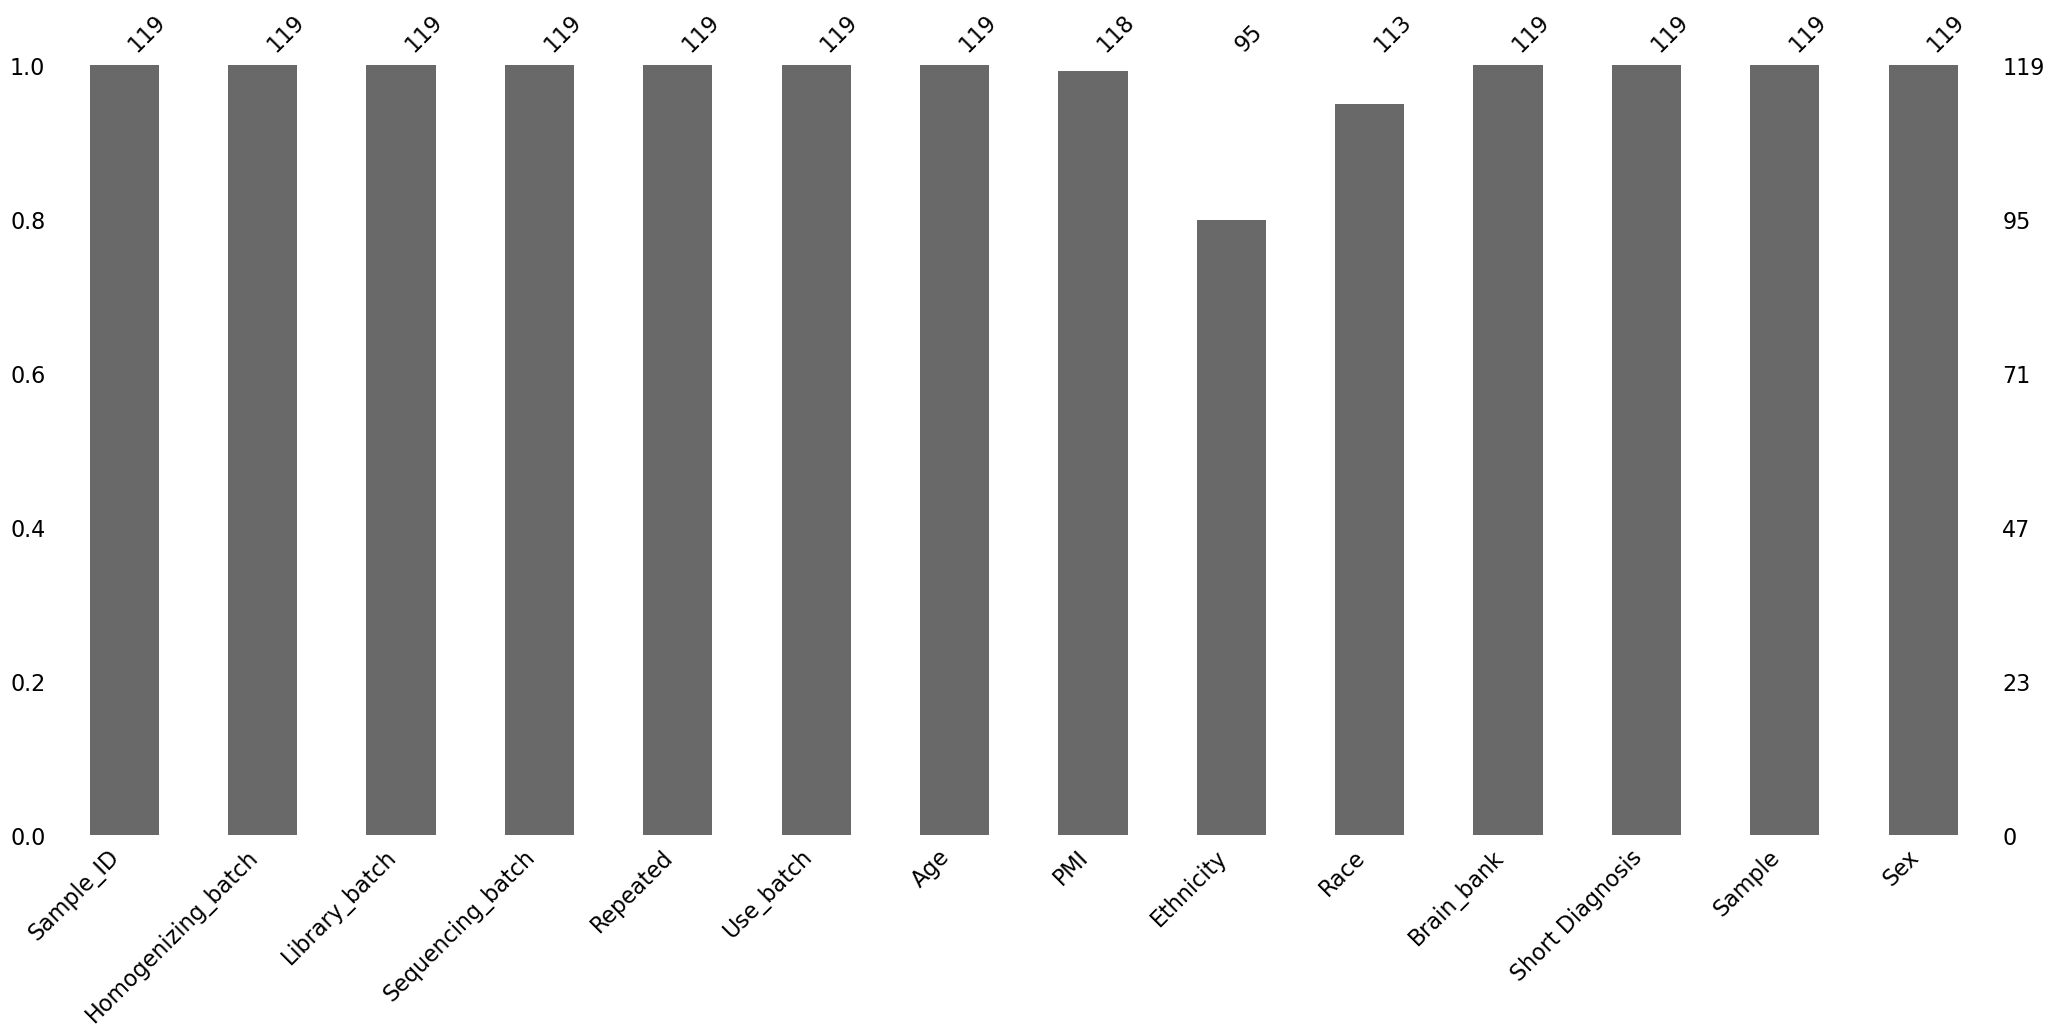

In [15]:
msno.bar(df)
plt.show()

### PLOTTING

Pick some col's to look at

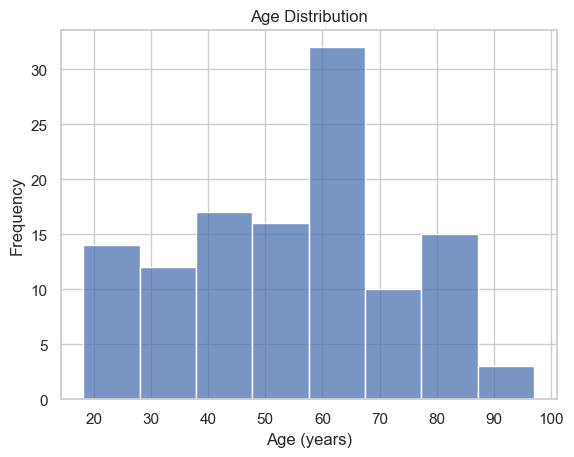

In [16]:
# Set Seaborn style
sns.set(style = 'whitegrid')

column_name = 'Age'

# PLOT - histogram
sns.histplot(df[column_name], kde = False)

# ADD - title and labels
plt.title(f'{column_name} Distribution')
plt.xlabel(f'{column_name} (years)')
plt.ylabel('Frequency')

# SHOW - plot
plt.show()

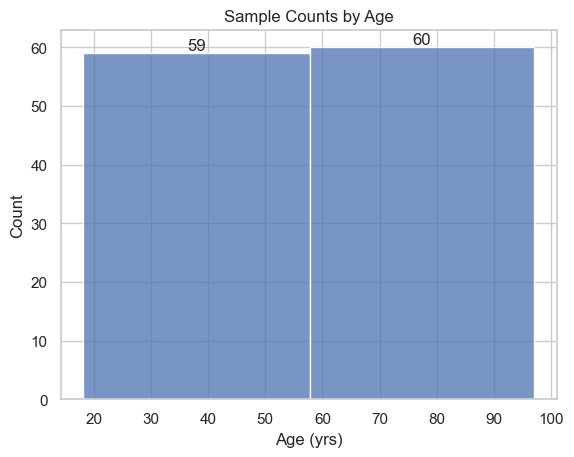

In [17]:
# Set Seaborn style
sns.set(style = 'whitegrid')

column_name = 'Age'

# PLOT - histogram plot
ax = sns.histplot(
    df[column_name], 
    bins = [df[column_name].min(), 57.8, df[column_name].max()],
    kde = False
)
ax.bar_label(ax.containers[0])

# ADD - title and labels
plt.title(f'Sample Counts by {column_name}')
plt.xlabel(f'{column_name} (yrs)')
plt.ylabel('Count')

# SHOW - plot
plt.show()

In [18]:
# CHECK - Count
column_name = 'Age'

# Set ranges
young_range = df[
    (df[column_name] >= df[column_name].min()) & 
    (df[column_name] < 57.9)
]
print('len(young_range) =', len(young_range))

old_range = df[
    (df[column_name] <= df[column_name].max()) & 
    (df[column_name] >= 57.9)
]
print('len(old_range) =', len(old_range))

# Count samples in each range
total_samples = len(young_range) + len(old_range)
print('total_samples = ', total_samples)

assert len(df) == total_samples, 'ERROR! -- Counts do not match!'

len(young_range) = 59
len(old_range) = 60
total_samples =  119


#? Q) What units are the PMIs?

#? A) Hours

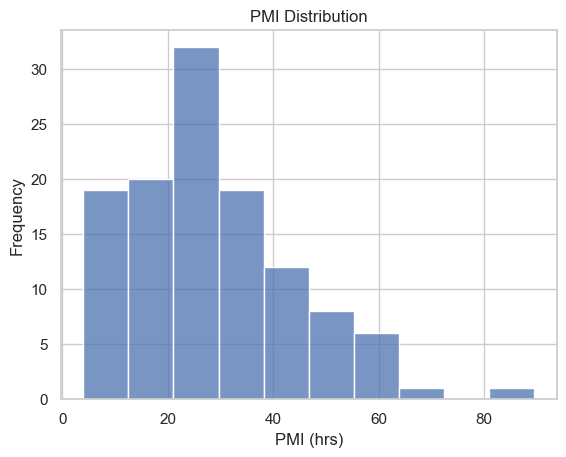

In [19]:
# Set Seaborn style
sns.set(style = 'whitegrid')

column_name = 'PMI'

# PLOT - histogram
sns.histplot(df[column_name], kde = False)

# ADD - title and labels
plt.title(f'{column_name} Distribution')
plt.xlabel(f'{column_name} (hrs)')
plt.ylabel('Frequency')

# SHOW - plot
plt.show()

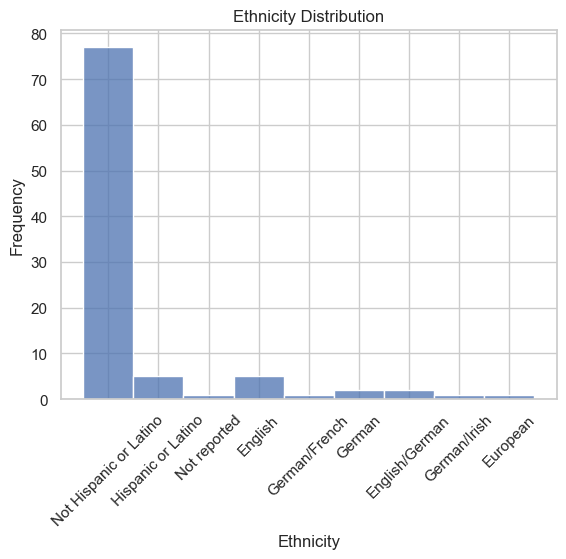

In [20]:
# Set Seaborn style
sns.set(style='whitegrid')

column_name = 'Ethnicity'

# PLOT - histogram
sns.histplot(df[column_name], kde=False)

# ADD - title and labels
plt.title(f'{column_name} Distribution')
plt.xlabel(f'{column_name}')
plt.ylabel('Frequency')

# ROTATE - x-axis labels
plt.xticks(rotation = 45)

# SHOW - plot
plt.show()

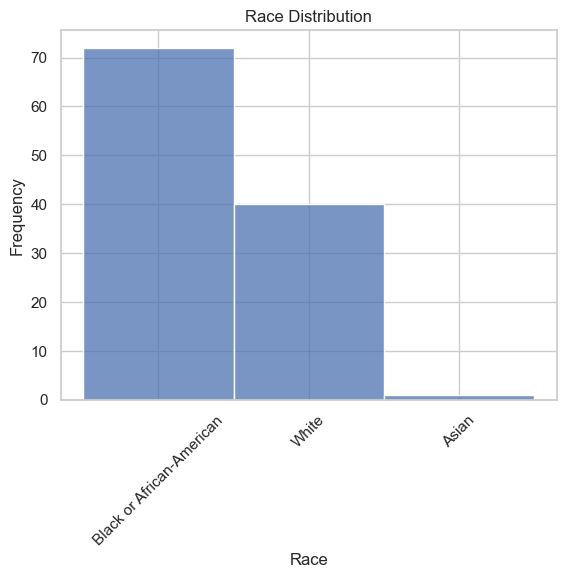

In [21]:
# Set Seaborn style
sns.set(style='whitegrid')

column_name = 'Race'

# PLOT - histogram
sns.histplot(df[column_name], kde=False)

# ADD - title and labels
plt.title(f'{column_name} Distribution')
plt.xlabel(f'{column_name}')
plt.ylabel('Frequency')

# ROTATE - x-axis labels
plt.xticks(rotation = 45)

# SHOW - plot
plt.show()

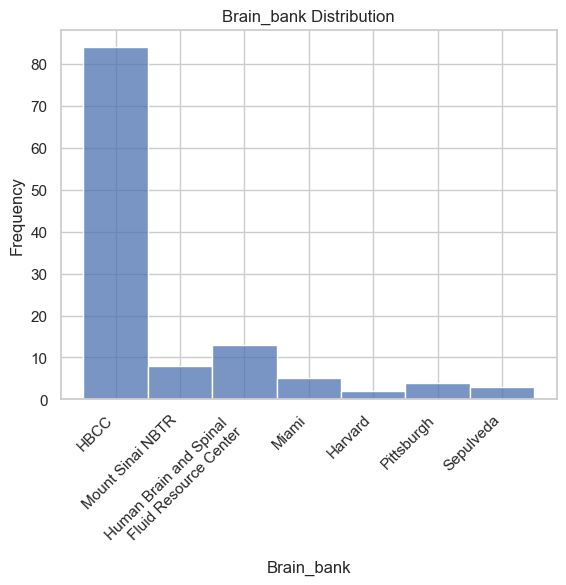

In [22]:
# Set Seaborn style
sns.set(style='whitegrid')

column_name = 'Brain_bank'

# PLOT - histogram
sns.histplot(df[column_name], kde=False)

# ADD - title and labels
plt.title(f'{column_name} Distribution')
plt.xlabel(f'{column_name}')
plt.ylabel('Frequency')

# SEPARATE - x-axis labels
plt.xticks(rotation=45, ha='right')

# ROTATE - x-axis labels
plt.xticks(rotation = 45)

# SHOW - plot
plt.show()

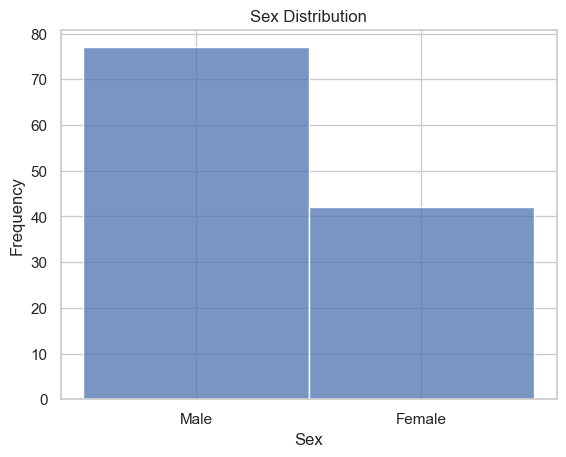

In [23]:
# Set Seaborn style
sns.set(style='whitegrid')

column_name = 'Sex'

# PLOT - histogram
sns.histplot(df[column_name], kde=False)

# ADD - title and labels
plt.title(f'{column_name} Distribution')
plt.xlabel(f'{column_name}')
plt.ylabel('Frequency')

# SHOW - plot
plt.show()

In [24]:
# * TODO - change into a pie chart?

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# ANNDATA SECTION

SOURCE: [https://anndata.readthedocs.io/en/stable/tutorials/notebooks/getting-started.html](https://anndata.readthedocs.io/en/stable/tutorials/notebooks/getting-started.html)

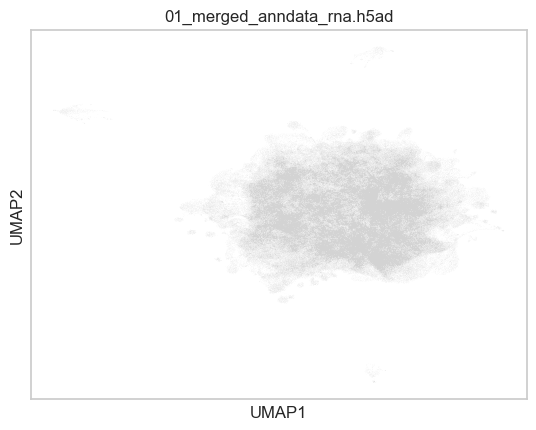

In [25]:
### INITIALIZING ANNDATA OBJECT
input_file_01 = os.path.join('/data/CARD_singlecell/Brain_atlas/SN_Multiome/control_atlas/01_merged_anndata_rna.h5ad')
adata_01 = sc.read_h5ad(input_file_01)
adata_01

#! WARNING - has its own output path 
# Define output path 
output_path = os.path.join('-adata_01-merged-umap.png')

# PLOT - umap by cell type using scanpy
sc.pl.umap(
    adata_01,
    title   = os.path.basename(input_file_01),
    save    = output_path,
    )

# print(f'Created file at: figures/{output_path}')

In [26]:
#* TODO - DELETE
adata_01.obs

,n_genes_by_counts,total_counts,total_counts_rb,pct_counts_rb,total_counts_mt,pct_counts_mt,doublet_score,cell_barcode,batch,sex,...,Brain_bank,Short Diagnosis,Sample,Sex,SampleID,Age_drop,Sex_drop,PMI_drop,Primary Diagnosis,Brain bank
TTCTTAGGTTAAATGC-1_890,14516,218515,766,0.350548,99,0.045306,0.098306,TTCTTAGGTTAAATGC-1,0.0,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACAAACTGTAAATTGC-1_890,12486,152765,645,0.422217,53,0.034694,0.120255,ACAAACTGTAAATTGC-1,0.0,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GCACGAACAATGAATG-1_890,12047,135894,466,0.342914,25,0.018397,0.108554,GCACGAACAATGAATG-1,0.0,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CCACAATAGTCAGGCC-1_890,11810,122505,303,0.247337,16,0.013061,0.087155,CCACAATAGTCAGGCC-1,0.0,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CTGCAATAGTGTTGCG-1_890,12369,107476,416,0.387063,95,0.088392,0.130180,CTGCAATAGTGTTGCG-1,0.0,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTTGTTCCATTGCGAC-1_SP5256,0,0,0,NaN,0,NaN,NaN,CTTGTTCCATTGCGAC-1,NaN,NaN,...,Sepulveda,Control,SP5256,Male,SP5256,61.0,Male,10.6,control,Sepulveda
GCCCGTTGTGGGAACA-1_SP5256,8,48,0,0.000000,47,97.916667,0.012577,GCCCGTTGTGGGAACA-1,NaN,NaN,...,Sepulveda,Control,SP5256,Male,SP5256,61.0,Male,10.6,control,Sepulveda
AATTTGGTCTCGCCCA-1_SP5256,8,97,0,0.000000,97,100.000000,0.010748,AATTTGGTCTCGCCCA-1,NaN,NaN,...,Sepulveda,Control,SP5256,Male,SP5256,61.0,Male,10.6,control,Sepulveda
TCTCACCAGTTTCCTG-1_SP5256,0,0,0,NaN,0,NaN,NaN,TCTCACCAGTTTCCTG-1,NaN,NaN,...,Sepulveda,Control,SP5256,Male,SP5256,61.0,Male,10.6,control,Sepulveda


In [27]:
# TEST
#* TODO - using the 01 preprocessed w/QC metrics, but NOT filtered yet: add histogram of mito, ribo, n_genes, doublet_scores

In [28]:
# TEST - turn these QC plots into a func

def plot_qc(df, column_name, input_file_path, log = False):
    
    # USER INPUTS
    column_name     = column_name
    df              = df
    input_file_path = input_file_path
    
    # Set Seaborn style
    sns.set(style='whitegrid')

    # PLOT - histogram
    g = sns.histplot(df[column_name], kde=False)

    if log == True:
        # Set y-axis to log scale
        g.set_yscale("log")

    # ADD - title and labels
    plt.title(f'{os.path.basename(input_file_path)} \n{column_name} Distribution')
    plt.xlabel(f'{column_name}')
    plt.ylabel('Frequency')

    # SHOW - plot
    plt.show()

In [ ]:
# TEST
plot_qc(
    df              = adata_01.obs, 
    column_name     = 'pct_counts_mt',
    input_file_path = input_file_01,
    log             = True,
    )

In [ ]:
plot_qc(
    df              = adata_01.obs, 
    column_name     = 'doublet_score',
    input_file_path = input_file_01
    )

In [ ]:
plot_qc(
    df              = adata_01.obs, 
    column_name     = 'n_genes_by_counts',
    input_file_path = input_file_01,
    log             = True,
    )

In [ ]:
plot_qc(
    df              = adata_01.obs, 
    column_name     = 'pct_counts_rb',
    input_file_path = input_file_01,
    log             = True,
    )

In [ ]:
# #* TODO - color by where you want your threshold

# threshold_dict = 

# adata_01.obs[adata_01.obs[column_name] >= threshold]

# 1/0

In [ ]:
# INITIALIZING ANNDATA OBJECT
input_file_03 = os.path.join('/data/CARD_singlecell/Brain_atlas/SN_Multiome/control_atlas/03_filtered_anndata_rna.h5ad')
adata_03 = sc.read_h5ad(input_file_03)
adata_03

#! WARNING - has its own output path 
# Define output path 
output_path = os.path.join('-adata_03-filtered-umap.png')

# PLOT - umap by cell type using scanpy
sc.pl.umap(
    adata_03,
    title   = os.path.basename(input_file_03),
    save    = output_path,
    )

# print(f'Created file at: figures/{output_path}')

In [ ]:
plot_qc(
    df              = adata_03.obs, 
    column_name     = 'pct_counts_mt',
    input_file_path = input_file_03,
    log             = True,
    )

In [ ]:
plot_qc(
    df              = adata_03.obs, 
    column_name     = 'doublet_score',
    input_file_path = input_file_03,
    # log             = True,
    )

In [ ]:
plot_qc(
    df              = adata_03.obs, 
    column_name     = 'n_genes_by_counts',
    input_file_path = input_file_03,
    log             = True,
    )

In [ ]:
plot_qc(
    df              = adata_03.obs, 
    column_name     = 'pct_counts_rb',
    input_file_path = input_file_03,
    log             = True,
    )

RERUN - the QC plots w/the filtered 03 file
* TODO - using the 03 filtered file, run the same histograms to see if it's been applied

In [ ]:
# TEST
# Define output file path for my testing, base on the original file name
output_file = os.path.join('output', os.path.basename(input_file_03).replace('.h5ad', '-ef-TEST.h5ad'))

# SAVE - new anndata object to a file w/the threshold filtered
adata = adata_03[adata_03.obs['n_genes_by_counts'] > 250].copy()
adata.write_h5ad(output_file, compression = 'gzip')

# RELOAD - my saved AnnData object
adata_03_filtered = sc.read_h5ad(output_file)
adata_03_filtered

# CHECK - file path
print('output_file =', output_file)
# 03_filtered_anndata_rna-ef-TEST.h5ad

In [ ]:
# TEST - make new UMAP for
sc.pl.umap(
    adata_03_filtered,
    title   = 'TEST',
    # save    = output_path,
    )

In [ ]:
plot_qc(
    df              = adata_03_filtered.obs, 
    column_name     = 'pct_counts_mt',
    input_file_path = input_file_03,
    log             = True,
    )

In [ ]:
plot_qc(
    df              = adata_03_filtered.obs, 
    column_name     = 'doublet_score',
    input_file_path = input_file_03,
    # log             = True,
    )

In [ ]:
plot_qc(
    df              = adata_03_filtered.obs, 
    column_name     = 'n_genes_by_counts',
    input_file_path = input_file_03,
    log             = True,
    )

In [ ]:
plot_qc(
    df              = adata_03_filtered.obs, 
    column_name     = 'pct_counts_rb',
    input_file_path = input_file_03,
    log             = True,
    )

In [ ]:
# TEST
print("adata_01.obs['n_genes_by_counts'].describe() = \n", adata_01.obs['n_genes_by_counts'].describe(), "\n")

print("adata_03.obs['n_genes_by_counts'].describe() = \n", adata_03.obs['n_genes_by_counts'].describe(), "\n")

print("adata_03_filtered.obs['n_genes_by_counts'].describe() = \n", adata_03_filtered.obs['n_genes_by_counts'].describe(), "\n")

In [ ]:
# INITIALIZING ANNDATA OBJECT
input_file_04 = os.path.join('/data/CARD_singlecell/Brain_atlas/SN_Multiome/control_atlas/04_modeled_anndata_rna.h5ad')
adata_04 = sc.read_h5ad(input_file_04)
adata_04

#! WARNING - has its own output path 
# Define output path 
output_path = os.path.join('-adata_4-filtered-umap.png')

# PLOT - umap by cell type using scanpy
sc.pl.umap(
    adata_04,
    title   = os.path.basename(input_file_04),
    save    = output_path,
    )

# print(f'Created file at: figures/{output_path}')

### DEFINE PATHS

In [47]:
input_file = os.path.join('/data/CARD_singlecell/Brain_atlas/SN_Multiome/control_atlas/05_annotated_anndata_rna.h5ad')

### INITIALIZING ANNDATA OBJECT

ADAM: try importing with `sc.read.h5ad`

In [48]:
adata = sc.read_h5ad(input_file)
adata

AnnData object with n_obs × n_vars = 426054 × 35590
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_rb', 'pct_counts_rb', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'cell_barcode', 'batch', 'sex', 'age', 'pmi', 'ethnicity', 'race', 'brain_bank', 'homogenization', 'library', 'seq', 'sample', 'short diagnosis', 'S_score', 'G2M_score', 'phase', 'n_counts', 'atlas_identifier', 'leiden_2', 'leiden', 'leiden_05', 'cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mt', 'rb'
    uns: 'hvg', 'leiden', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_scvi', 'X_umap', 'ora_estimate', 'ora_pvals'
    layers: 'counts', 'cpm', 'data'
    obsp: 'connectivities', 'distances'

In [49]:
adata.obs

,n_genes_by_counts,total_counts,total_counts_rb,pct_counts_rb,total_counts_mt,pct_counts_mt,doublet_score,cell_barcode,batch,sex,...,short diagnosis,S_score,G2M_score,phase,n_counts,atlas_identifier,leiden_2,leiden,leiden_05,cell_type
GCACGAACAATGAATG-1_890,12047,135894,466,0.342914,25,0.018397,0.108554,GCACGAACAATGAATG-1,0.0,Male,...,Control,-4.616686,-4.344281,G1,1882.529319,GCACGAACAATGAATG-1_890,37,25,13,DaN
CCACAATAGTCAGGCC-1_890,11810,122505,303,0.247337,16,0.013061,0.087155,CCACAATAGTCAGGCC-1,0.0,Male,...,Control,-4.091303,-2.780126,G1,1954.518169,CCACAATAGTCAGGCC-1_890,32,19,11,ExN
CTGCAATAGTGTTGCG-1_890,12369,107476,416,0.387063,95,0.088392,0.130180,CTGCAATAGTGTTGCG-1,0.0,Male,...,Control,-2.962416,-2.134167,G1,1974.325967,CTGCAATAGTGTTGCG-1_890,32,19,11,ExN
GAGTGAGGTCATGAGC-1_890,11701,112072,437,0.389928,24,0.021415,0.120255,GAGTGAGGTCATGAGC-1,0.0,Male,...,Control,-3.701495,-3.039490,G1,1927.224464,GAGTGAGGTCATGAGC-1_890,37,25,13,DaN
GCTCAACCAGCATGTC-1_890,9017,91164,2116,2.321092,1498,1.643192,0.079328,GCTCAACCAGCATGTC-1,0.0,Male,...,Control,-2.371704,-3.103461,G1,1761.063659,GCTCAACCAGCATGTC-1_890,36,24,10,PC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATTTAGGTCATAACCA-1_SP5256,424,579,0,0.000000,0,0.000000,0.064363,ATTTAGGTCATAACCA-1,7.0,Male,...,Control,-0.004104,-0.011658,G1,NaN,ATTTAGGTCATAACCA-1_SP5256,0,3,4,Oligo
GCTAAGAAGGCAATAG-1_SP5256,464,568,2,0.352113,0,0.000000,0.073468,GCTAAGAAGGCAATAG-1,7.0,Male,...,Control,-0.008208,-0.011658,G1,NaN,GCTAAGAAGGCAATAG-1_SP5256,8,5,7,Oligo
AGCCTAGTCCTCATCA-1_SP5256,512,661,0,0.000000,0,0.000000,0.041814,AGCCTAGTCCTCATCA-1,7.0,Male,...,Control,-0.013680,-0.014249,G1,NaN,AGCCTAGTCCTCATCA-1_SP5256,15,6,4,Oligo
AGCAAGGGTGGATTGC-1_SP5256,413,517,1,0.193424,6,1.160542,0.084414,AGCAAGGGTGGATTGC-1,7.0,Male,...,Control,0.016970,-0.012953,S,NaN,AGCAAGGGTGGATTGC-1_SP5256,2,4,1,Oligo


### PLOT - using scanpy

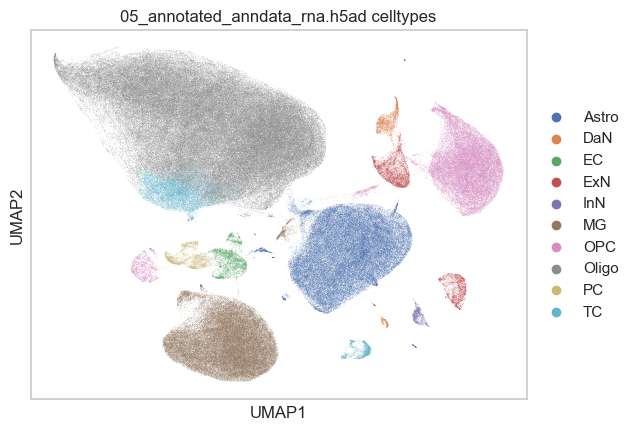

In [50]:
#! WARNING - has its own output path 
output_path = os.path.join('-adata_05-annotated-umap.png')

# # PLOT - umap by cell type using scanpy
# sc.pl.umap(adata, color='cell_type')

# PLOT - umap by cell type using scanpy
sc.pl.umap(
    adata,
    color   = 'cell_type',
    title   = f'{os.path.basename(input_file)} celltypes',
    save    = output_path,
    )

# print(f'Created file at: figures/umap{output_path}')

In [51]:
# # TEST - on old ARCHIVED files
# # RELOAD
# input_file = os.path.join('/data/CARD_singlecell/Brain_atlas/SN_Multiome/control_atlas/ARCHIVE/05_annotated_anndata_rna.h5ad')
# adata = sc.read_h5ad(input_file)
# adata

# FIX - the wrong spelling

In [52]:
# Find the typo and overwrite
adata.obs['brain_bank'] = adata.obs['brain_bank'].str.replace('Havard', 'Harvard')

# CHECK
len(adata.obs[adata.obs['brain_bank'] == 'Havard'])

0

In [53]:
# FILTER - by celltype = T-cells
TC = adata[adata.obs['cell_type'] == 'TC']
TC

View of AnnData object with n_obs × n_vars = 17189 × 35590
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_rb', 'pct_counts_rb', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'cell_barcode', 'batch', 'sex', 'age', 'pmi', 'ethnicity', 'race', 'brain_bank', 'homogenization', 'library', 'seq', 'sample', 'short diagnosis', 'S_score', 'G2M_score', 'phase', 'n_counts', 'atlas_identifier', 'leiden_2', 'leiden', 'leiden_05', 'cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mt', 'rb'
    uns: 'hvg', 'leiden', 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'X_pca', 'X_scvi', 'X_umap', 'ora_estimate', 'ora_pvals'
    layers: 'counts', 'cpm', 'data'
    obsp: 'connectivities', 'distances'

/data/fonge2/conda/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


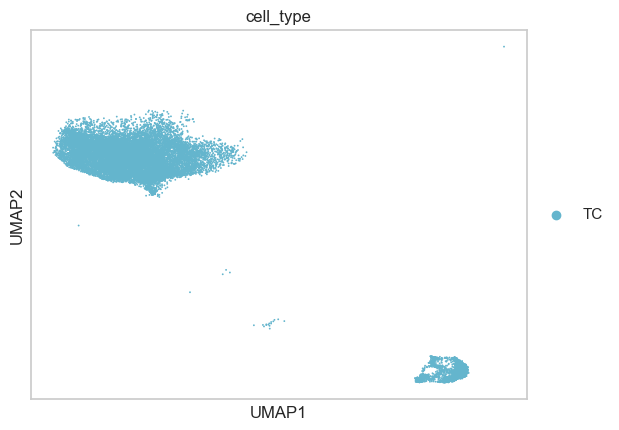

In [54]:
# PLOT - the T-cell filtered data
sc.pl.umap(
    TC, 
    color = 'cell_type')

In [55]:
# Log scaling of the palette
norm = mcolors.LogNorm()

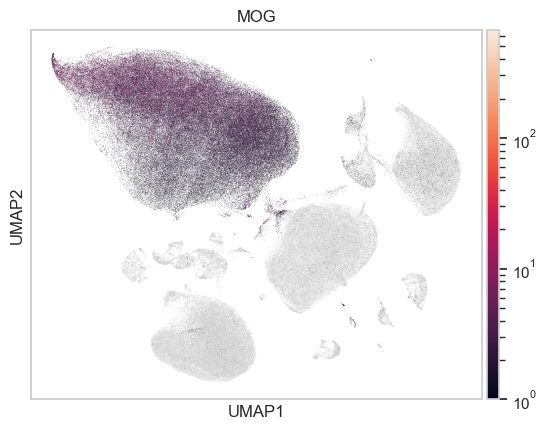

In [56]:
# TEST
sc.pl.umap(
    adata,
    norm = norm, 
    color = 'MOG'
)

#* TODO - use the old list of celltypes

- full on neuron types
- pick 2 for the rest
- use the Dot Plots section of the docs
- get some new markers from Xylena:
```
for DaN add     - TH, FOXA2, NR4A2, SLC6A3
for tCells      - CD3D, CD3E, CD8B, CD4
for pericytes   - CSPG4, ATP13A5, PDGFRB
```

categories: Astro, DaN, EC, etc.
var_group_labels: ExN, InN, MG, etc.


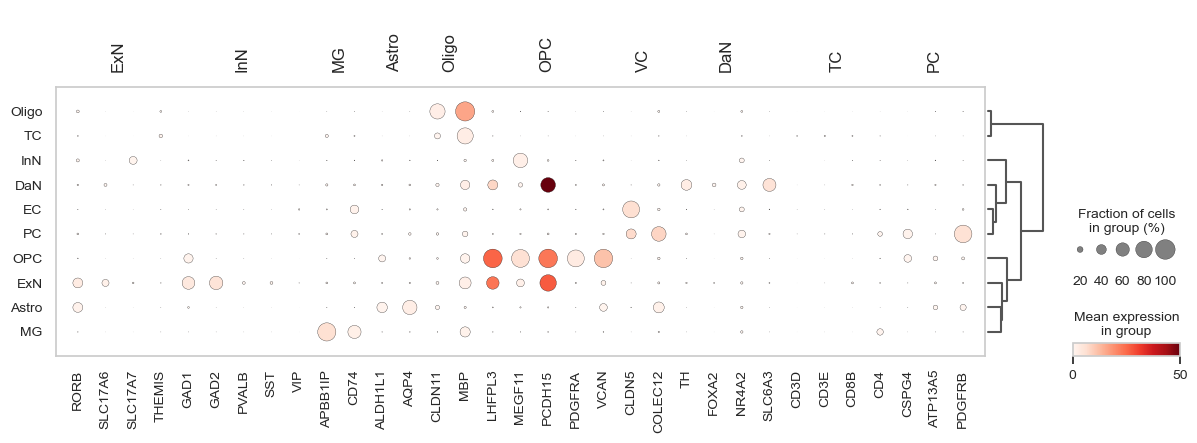

In [57]:
# TEST - Xylena's marker list

celltype_markers_dict = {
    'ExN'   : ['RORB', 'SLC17A6', 'SLC17A7', 'THEMIS'],
    'InN'   : ['GAD1', 'GAD2', 'PVALB', 'SST', 'VIP'],
    'MG'    : ['APBB1IP', 'CD74'],
    'Astro' : ['ALDH1L1', 'AQP4'],
    'Oligo' : ['CLDN11', 'MBP'],
    'OPC'   : ['LHFPL3', 'MEGF11', 'PCDH15', 'PDGFRA', 'VCAN'],
    'VC'    : ['CLDN5', 'COLEC12'],
    'DaN'   : ['TH', 'FOXA2', 'NR4A2', 'SLC6A3'],
    'TC'    : ['CD3D', 'CD3E', 'CD8B', 'CD4'],
    'PC'    : ['CSPG4', 'ATP13A5', 'PDGFRB']
}

sc.pl.dotplot(
    adata, 
    celltype_markers_dict, 
    'cell_type', 
    dendrogram = True
)

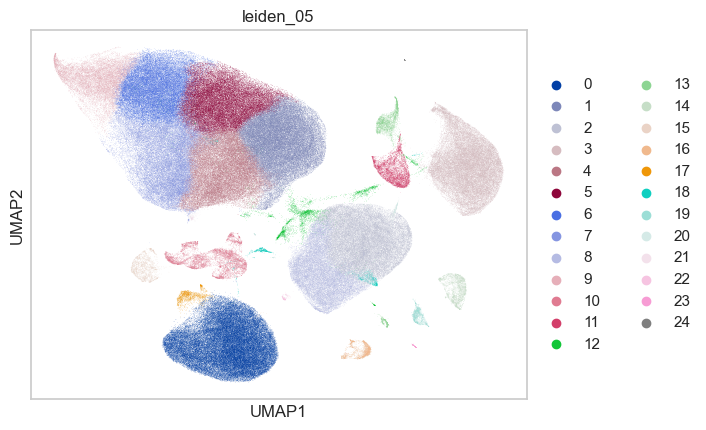

In [ ]:
# TEST - alternative clustering method
sc.pl.umap(
    adata,
    color = 'leiden_05'
)

categories: 0, 1, 2, etc.
var_group_labels: ExN, InN, MG, etc.


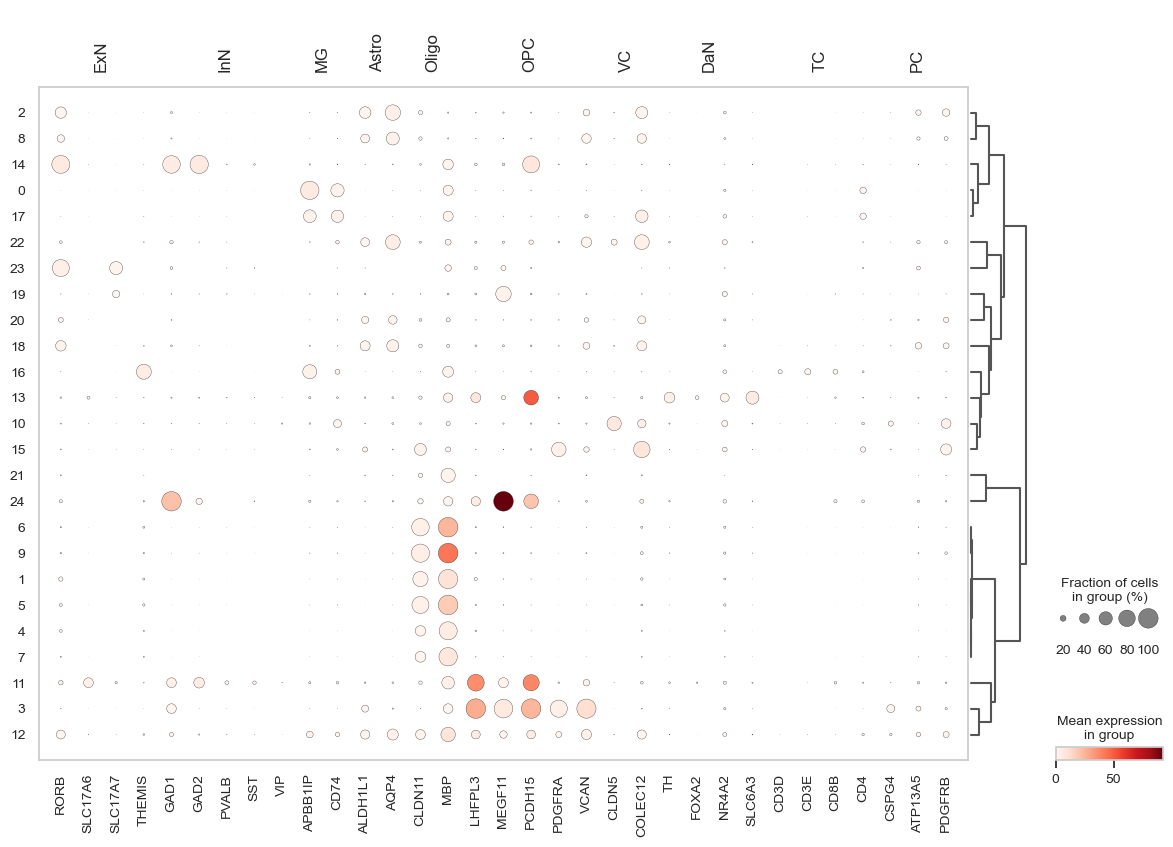

In [59]:
# TEST - alternative clustering method
# TEST - Xylena's marker list but using leiden_05 for the clustering

celltype_markers_dict = {
    'ExN'   : ['RORB', 'SLC17A6', 'SLC17A7', 'THEMIS'],
    'InN'   : ['GAD1', 'GAD2', 'PVALB', 'SST', 'VIP'],
    'MG'    : ['APBB1IP', 'CD74'],
    'Astro' : ['ALDH1L1', 'AQP4'],
    'Oligo' : ['CLDN11', 'MBP'],
    'OPC'   : ['LHFPL3', 'MEGF11', 'PCDH15', 'PDGFRA', 'VCAN'],
    'VC'    : ['CLDN5', 'COLEC12'],
    'DaN'   : ['TH', 'FOXA2', 'NR4A2', 'SLC6A3'],
    'TC'    : ['CD3D', 'CD3E', 'CD8B', 'CD4'],
    'PC'    : ['CSPG4', 'ATP13A5', 'PDGFRB']
}

sc.pl.dotplot(
    adata, 
    celltype_markers_dict, 
    'leiden_05', 
    dendrogram = True
)

# TEST - Human Protein Atlas (+ Gene Cards) searching for TC markers 

### REF LINKS:

- LAT2: https://www.proteinatlas.org/ENSG00000086730-LAT2/brain 
  - Might be activated MG?
- NFATC3: https://www.proteinatlas.org/ENSG00000072736-NFATC3/brain
  - showed up in every celltype cluster (don't use)
- NFATC4: https://www.proteinatlas.org/ENSG00000100968-NFATC4/brain 
- MTPC1: https://www.genecards.org/cgi-bin/carddisp.pl?gene=MTCP1 

categories: Astro, DaN, EC, etc.
var_group_labels: ExN, InN, MG, etc.


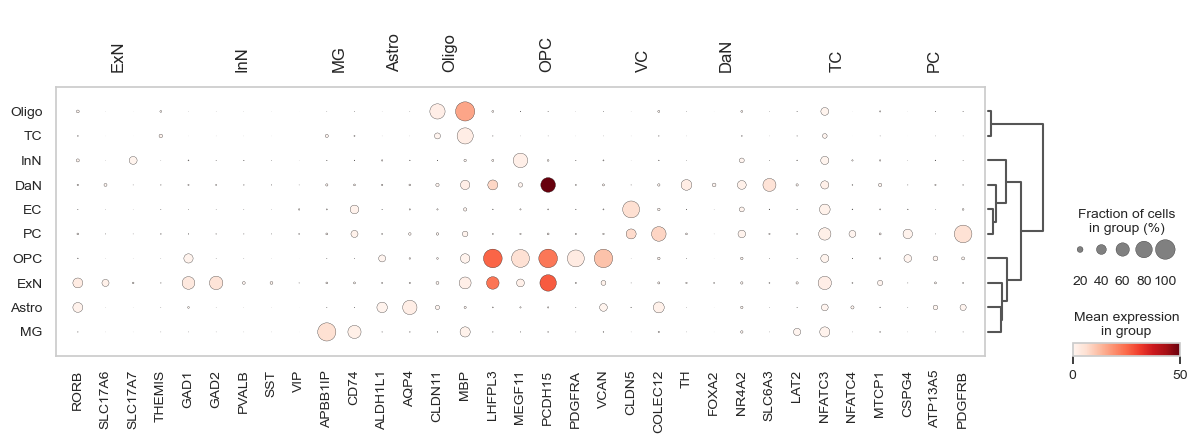

In [60]:
# TEST - Human Protein Atlas (+ Gene Cards) searching for TC markers 

celltype_markers_dict = {
    'ExN'   : ['RORB', 'SLC17A6', 'SLC17A7', 'THEMIS'],
    'InN'   : ['GAD1', 'GAD2', 'PVALB', 'SST', 'VIP'],
    'MG'    : ['APBB1IP', 'CD74'],
    'Astro' : ['ALDH1L1', 'AQP4'],
    'Oligo' : ['CLDN11', 'MBP'],
    'OPC'   : ['LHFPL3', 'MEGF11', 'PCDH15', 'PDGFRA', 'VCAN'],
    'VC'    : ['CLDN5', 'COLEC12'],
    'DaN'   : ['TH', 'FOXA2', 'NR4A2', 'SLC6A3'],
    # 'TC'    : ['CD3D', 'CD3E', 'CD8B', 'CD4'],
    'TC'    : ['LAT2', 'NFATC3', 'NFATC4', 'MTCP1'], 
    'PC'    : ['CSPG4', 'ATP13A5', 'PDGFRB']
}

sc.pl.dotplot(
    adata, 
    celltype_markers_dict, 
    'cell_type', 
    dendrogram = True
)

# TEST - New paper looking at DaN markers

### REF: https://www.sciencedirect.com/science/article/pii/S2211124724001128

WARNING: model is mouse, not human!

Strongly specific, yet understudied:

- Slc10a4
- Cpne7

Commonly enriched between glia and DA neurons:

- Ctsb,
- Dpm3, 
- Inpp5f, 
- Rps12, 
- Sbds, 
- Scarb2, 
- Stx4a 

Add to list:
```
'DaN' : ['SLC10A4', 'CPNE7', 'CTSB', 'DPM3', 'INPP5F', 'RPS12', 'SBDS', 'SCARB2'] #! ERROR: 'STX4A' missing
```

MY RESULTS:

- SLC10A4   --> ok
- Cpne7     --> getting worse
- the rest aren't specific

In [66]:
# # TEMP - delete
# list = ['Slc10a4', 'Cpne7', 'Ctsb', 'Dpm3', 'Inpp5f', 'Rps12', 'Sbds', 'Scarb2', 'Stx4a']
# uppercase_words = [word.upper() for word in list]
# print(uppercase_words)

categories: Astro, DaN, EC, etc.
var_group_labels: ExN, InN, MG, etc.


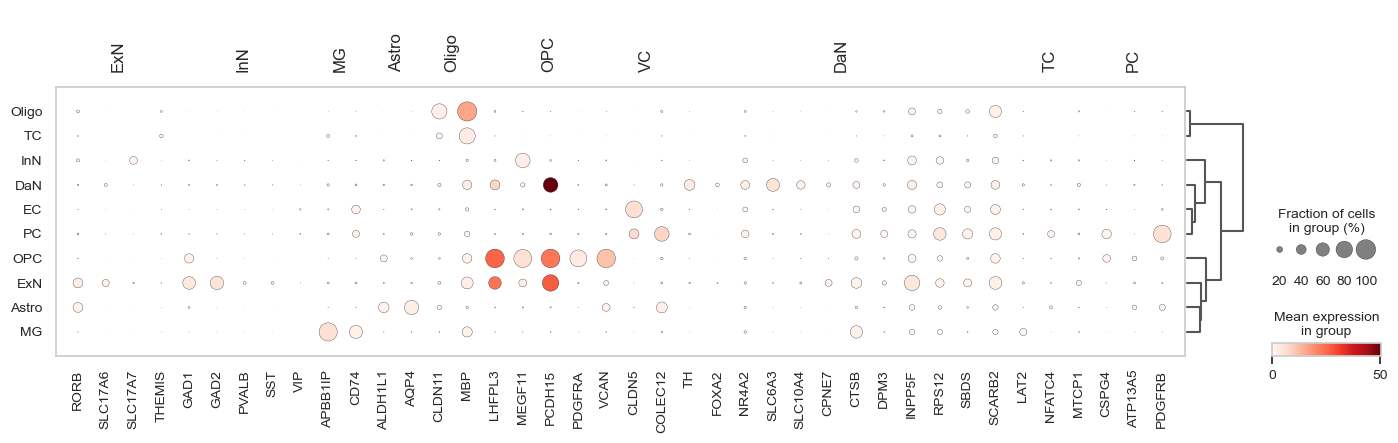

In [67]:
# TEST - New paper looking at DaN markers
# REF: https://www.sciencedirect.com/science/article/pii/S2211124724001128

celltype_markers_dict = {
    'ExN'   : ['RORB', 'SLC17A6', 'SLC17A7', 'THEMIS'],
    'InN'   : ['GAD1', 'GAD2', 'PVALB', 'SST', 'VIP'],
    'MG'    : ['APBB1IP', 'CD74'],
    'Astro' : ['ALDH1L1', 'AQP4'],
    'Oligo' : ['CLDN11', 'MBP'],
    'OPC'   : ['LHFPL3', 'MEGF11', 'PCDH15', 'PDGFRA', 'VCAN'],
    'VC'    : ['CLDN5', 'COLEC12'],
    'DaN'   : ['TH', 'FOXA2', 'NR4A2', 'SLC6A3', 'SLC10A4', 'CPNE7', 'CTSB', 'DPM3', 'INPP5F', 'RPS12', 'SBDS', 'SCARB2'], #! ERROR: 'STX4A' missing
    # 'TC'    : ['CD3D', 'CD3E', 'CD8B', 'CD4'],
    'TC'    : ['LAT2', 'NFATC3', 'NFATC4', 'MTCP1'], 
    'PC'    : ['CSPG4', 'ATP13A5', 'PDGFRB']
}

sc.pl.dotplot(
    adata, 
    celltype_markers_dict, 
    'cell_type', 
    dendrogram = True
)

# FEATURE PLOTS

#* TODO - feature plot of just the TC genes and anything else that looks weird on the dotplot

REF: https://scanpy.readthedocs.io/en/latest/tutorials/plotting/core.html#visualization-of-gene-expression-and-other-variables 

'TC'

- Xylena's celltype markers list: 
  - ['CD3D', 'CD3E', 'CD8B', 'CD4'],
- New ones from protein atlas + genebank: 
  - ['LAT2', 'NFATC3', 'NFATC4', 'MTCP1'],

scanpy==1.10.1 anndata==0.11.3 umap==0.5.6 numpy==2.1.3 scipy==1.14.0 pandas==2.2.3 scikit-learn==1.5.1 statsmodels==0.14.2 igraph==0.11.8 pynndescent==0.5.13


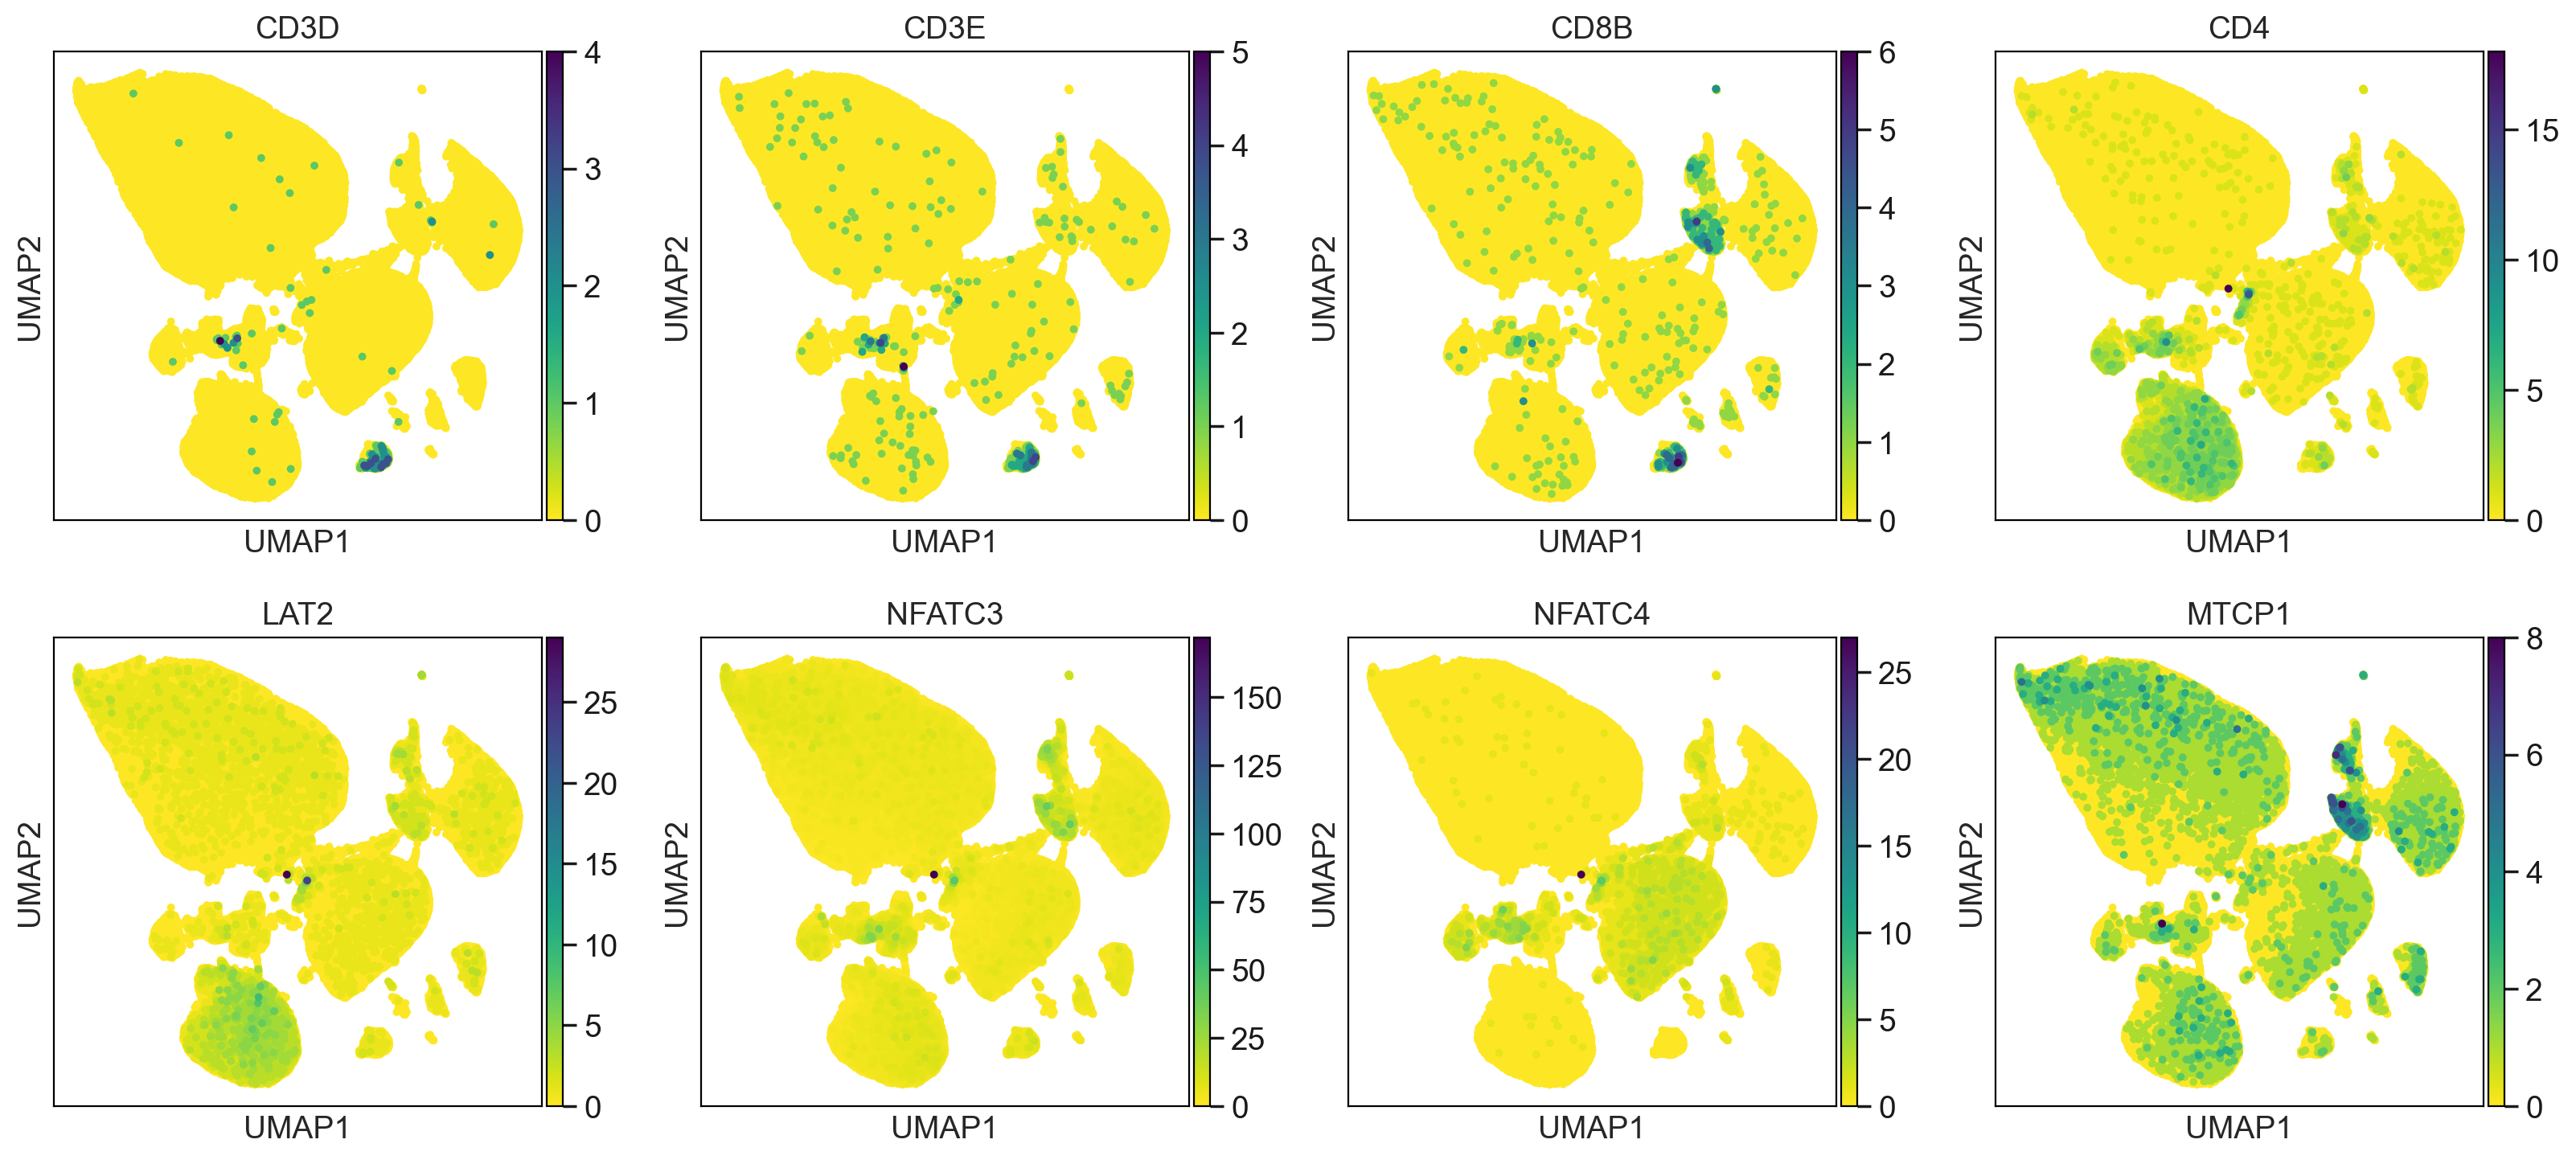

In [80]:
# SETUP
sc.set_figure_params(dpi=100, color_map="viridis_r")
sc.settings.verbosity = 0
sc.logging.print_header()

# CHANGE
celltype_markers_TC = ['CD3D', 'CD3E', 'CD8B', 'CD4', 'LAT2', 'NFATC3', 'NFATC4', 'MTCP1']

# rc_context is used for the figure size, in this case 4x4
with rc_context({"figure.figsize": (4, 4)}):
    sc.pl.umap(
        adata, 
        color = celltype_markers_TC,
        s = 50,
        ncols = int(round(len(celltype_markers_TC)/2))
    )

### TC:
```
CD3D  : (SELECT) shows up strongly in the bottom right TC cluster
CD3E  : (SELECT) shows up strongly in the bottom right TC cluster
CD8B  : shows up strongly in the bottom right TC cluster
CD4   : MG 
LAT2  : MG
NFATC3: everywhere!
NFATC4: Astro, PC, EC, OPC
MTCP1 : everwhere!
```

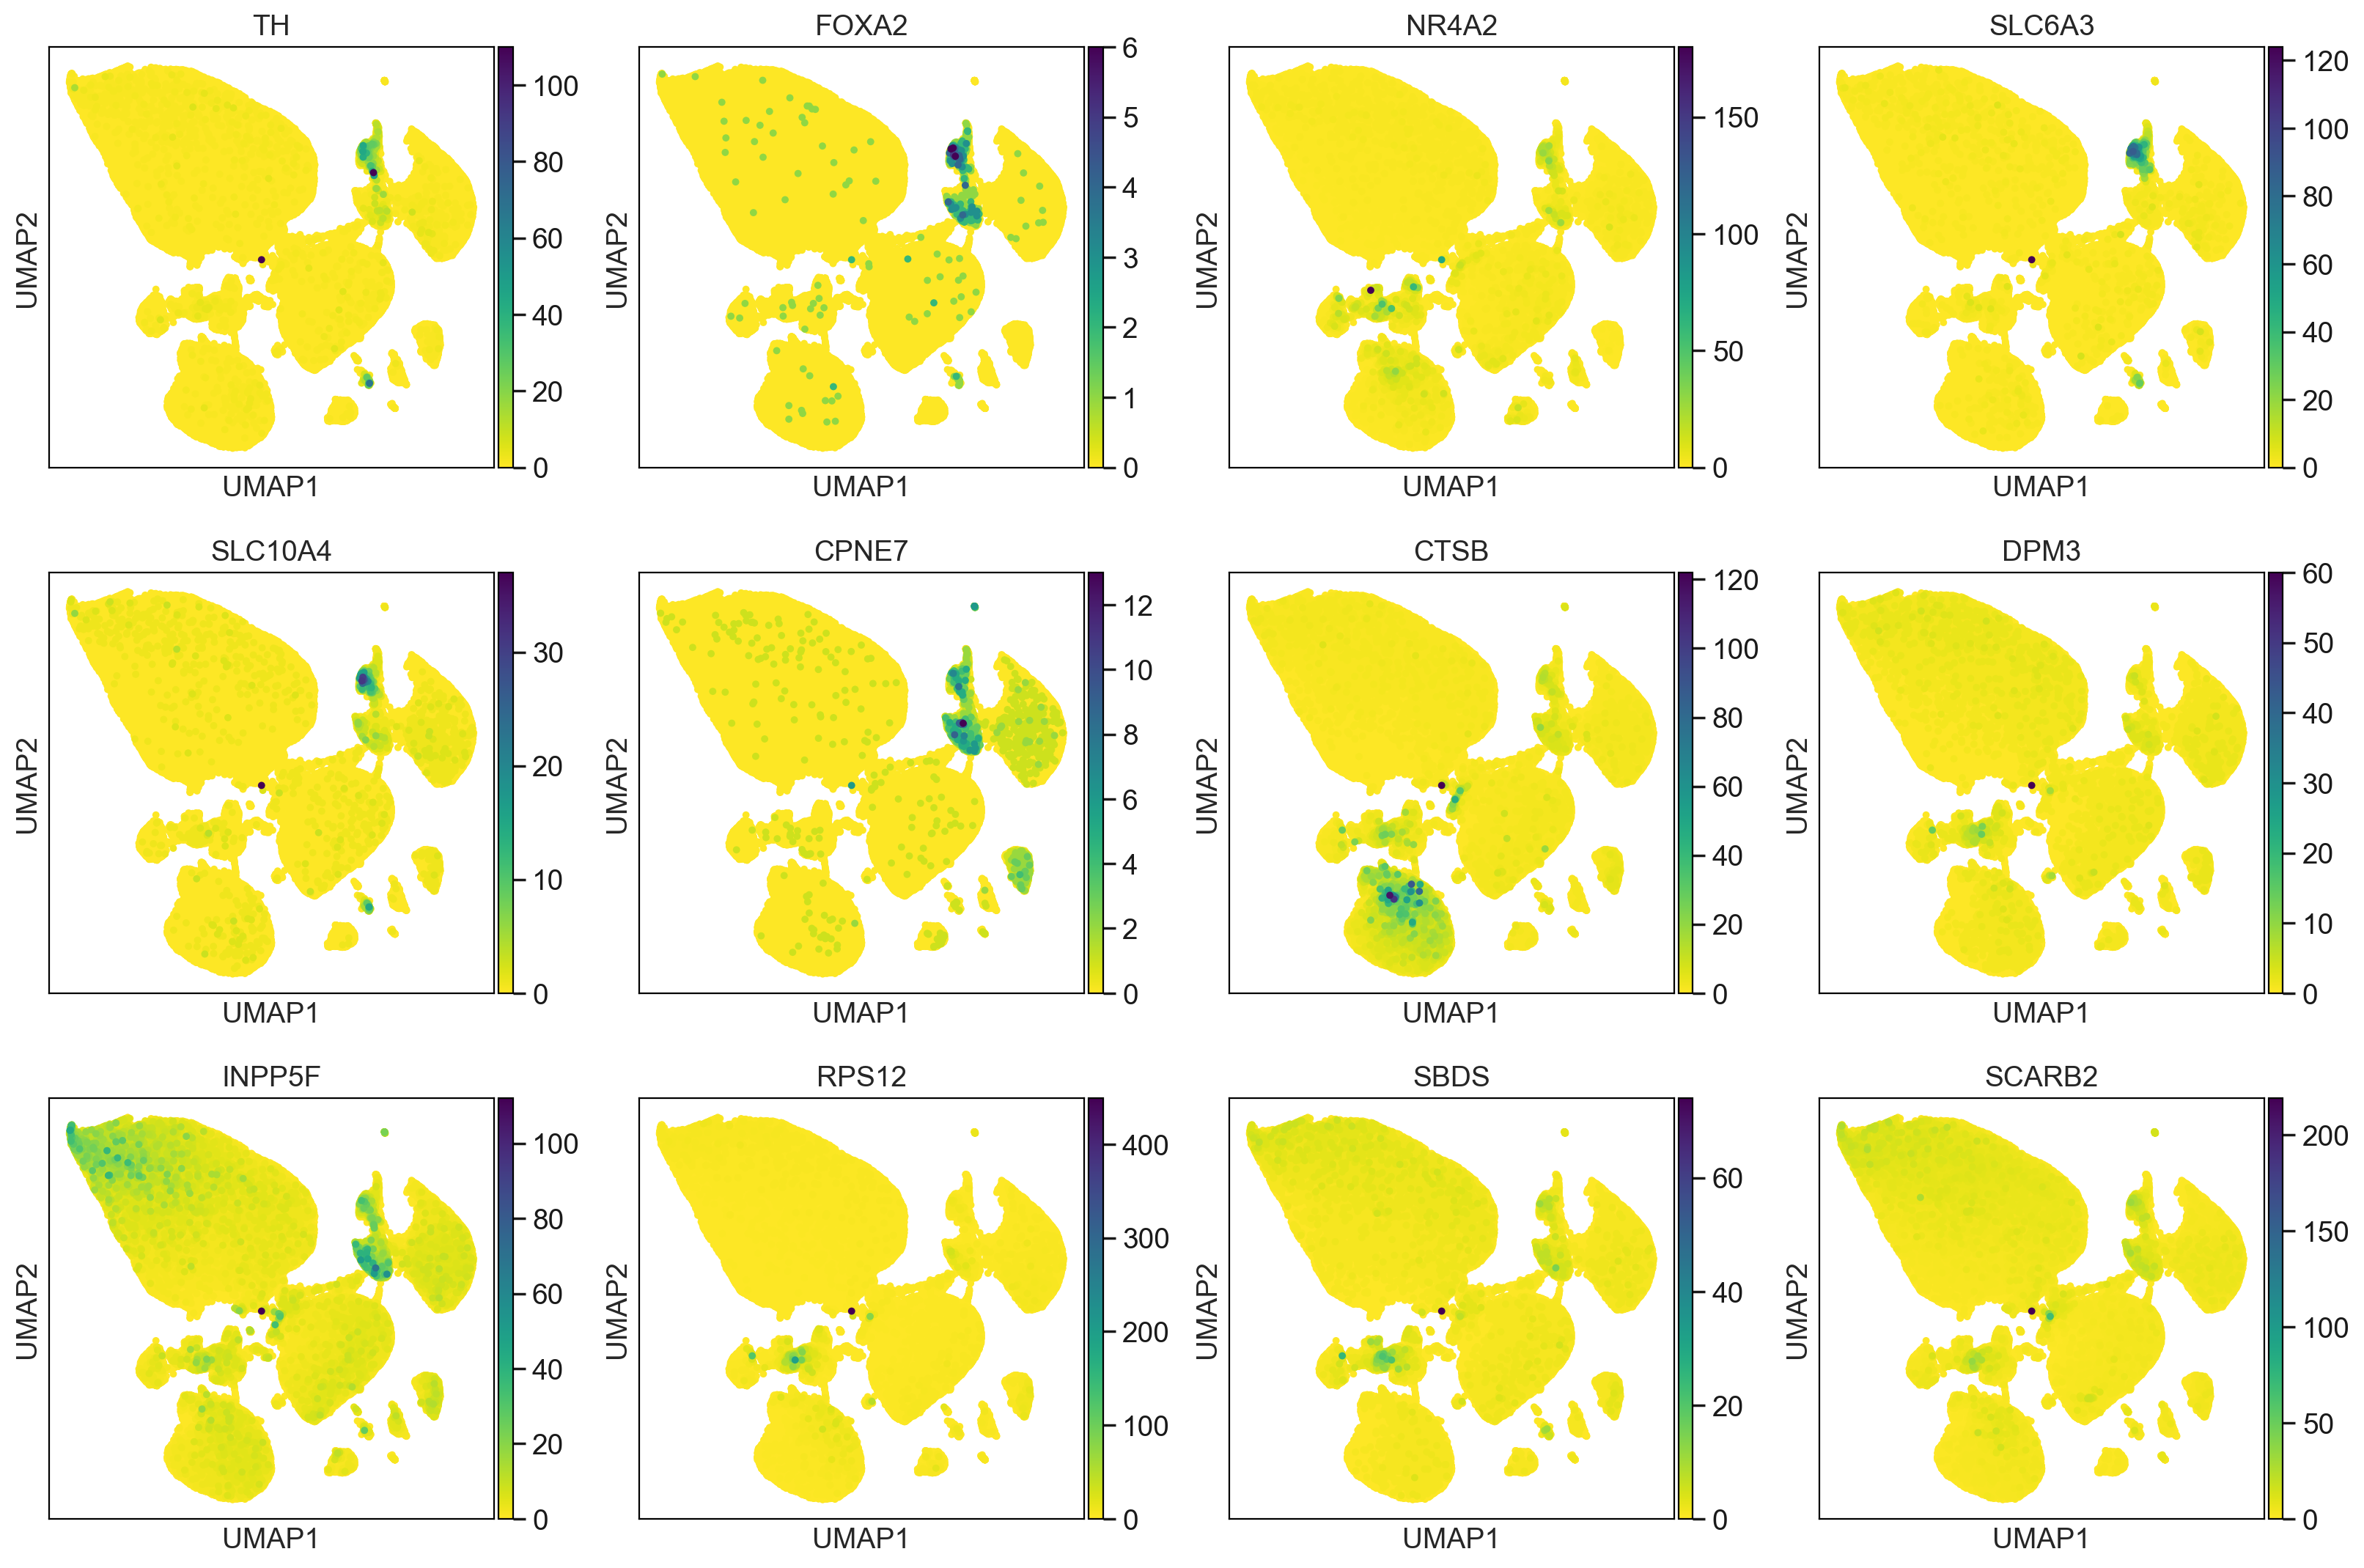

In [ ]:
# CHANGE
celltype_markers_DaN = ['TH', 'FOXA2', 'NR4A2', 'SLC6A3', 'SLC10A4', 'CPNE7', 'CTSB', 'DPM3', 'INPP5F', 'RPS12', 'SBDS', 'SCARB2']

# rc_context is used for the figure size, in this case 4x4
with rc_context({"figure.figsize": (4, 4)}):
    sc.pl.umap(
        adata, 
        color = celltype_markers_DaN,
        s = 50,
        ncols = int(round(len(celltype_markers_DaN)/3))
    )

### DaN:
```
TH      : (SELECT) DaN + ExN
FOXA2   : DaN + ExN
NR4A2   : lightly DaN
SLC6A3  : (SELECT) DaN
SLC10A4 : (SELECT) DaN
CPNE7   : DaN + ExN
CTSB    : MG
DPM3    : OPC + PC
INPP5F  : everywhere
RPS12   : EC 
SBDS    : OPC + PC + DaN + ExN everywhere
SCARB2  : OPC + PC + DaN + ExN everywhere
```

### #* TODO

- remake the dotplot w/my selected genes
- remake the UMAPs, keep the TCs in
- GOAL here: check to make sure the bottom of the Oligos is actually Oligo and NOT called TC
- THEN, rerun the DGE pipeline

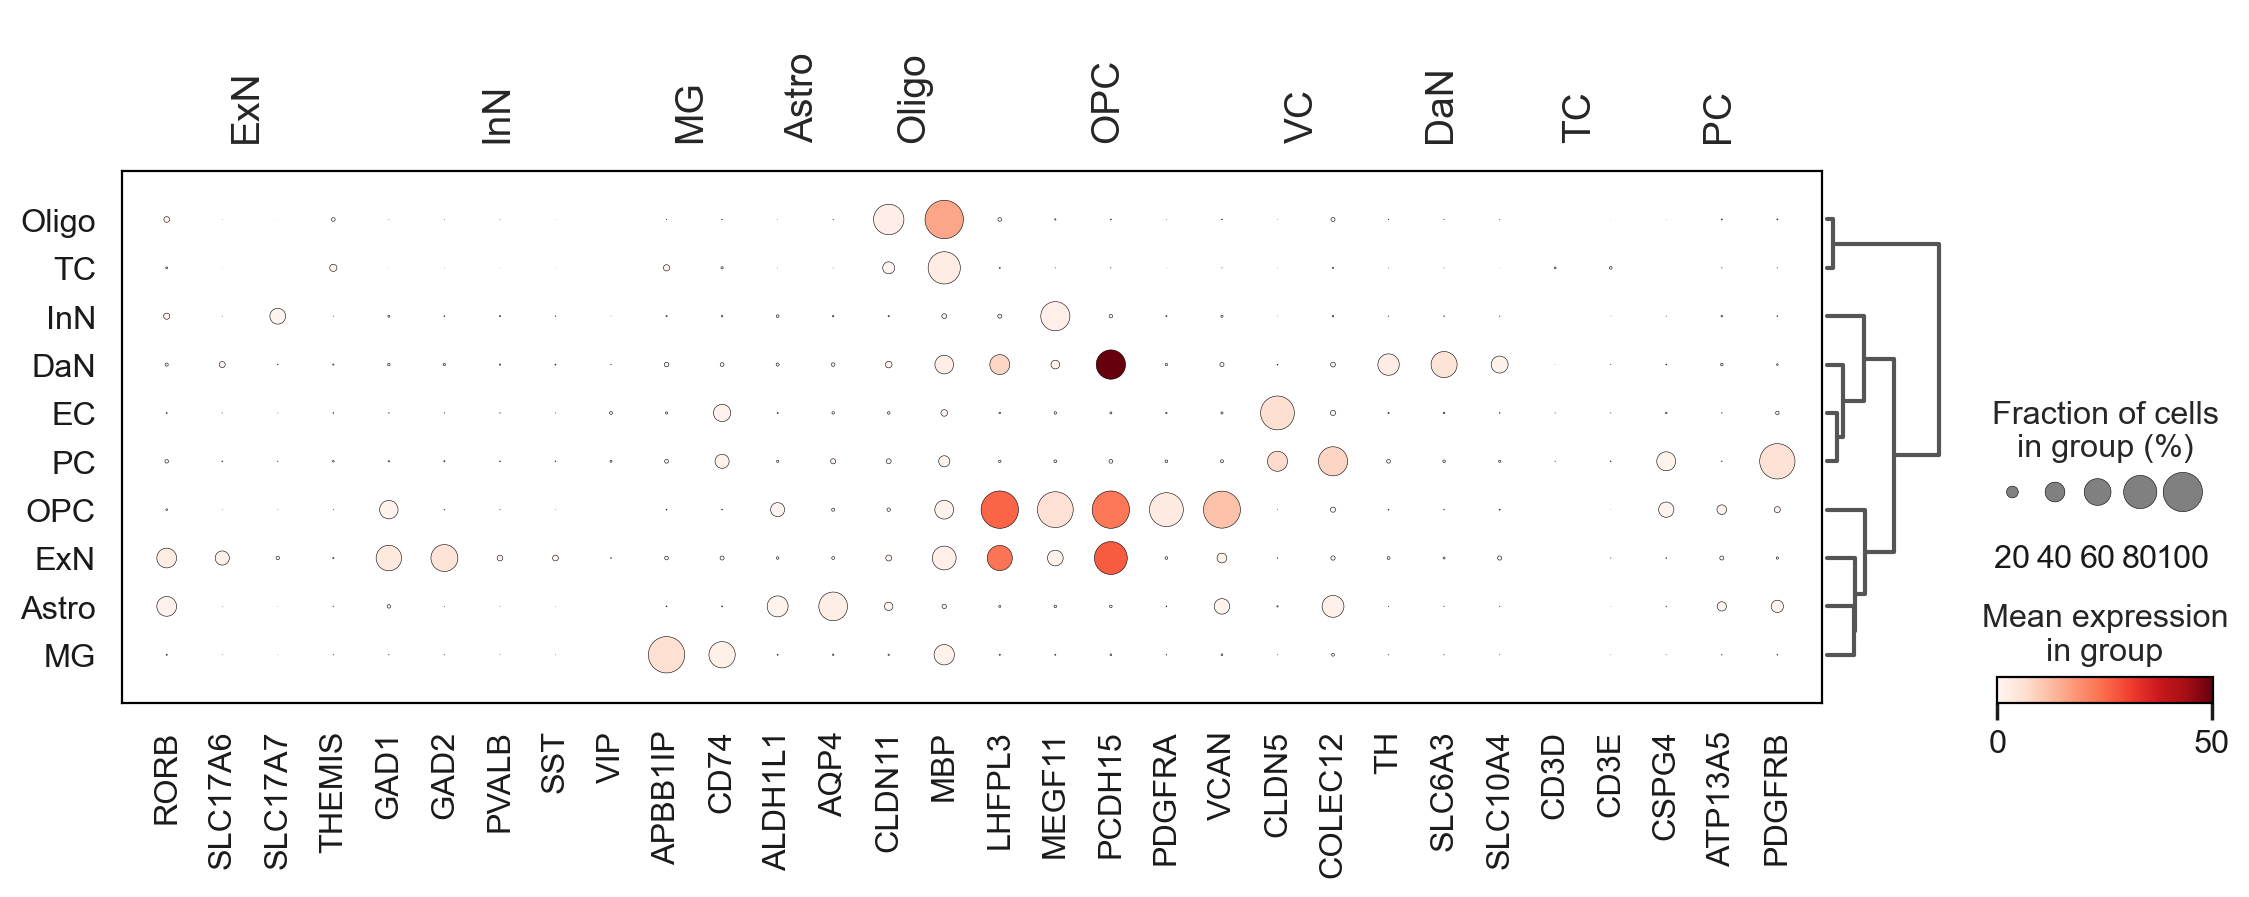

In [ ]:
# TEST - pick a few new celltype markers
#* TODO - edit the annotate snakemake rule w/the new Dan and TC markers

celltype_markers_dict = {
    'ExN'   : ['RORB', 'SLC17A6', 'SLC17A7', 'THEMIS'],
    'InN'   : ['GAD1', 'GAD2', 'PVALB', 'SST', 'VIP'],
    'MG'    : ['APBB1IP', 'CD74'],
    'Astro' : ['ALDH1L1', 'AQP4'],
    'Oligo' : ['CLDN11', 'MBP'],
    'OPC'   : ['LHFPL3', 'MEGF11', 'PCDH15', 'PDGFRA', 'VCAN'],
    'VC'    : ['CLDN5', 'COLEC12'],
    'DaN'   : ['TH', 'SLC6A3', 'SLC10A4'],
    'TC'    : ['CD3D', 'CD3E'],
    'PC'    : ['CSPG4', 'ATP13A5', 'PDGFRB']
}

sc.pl.dotplot(
    adata, 
    celltype_markers_dict, 
    'cell_type', 
    dendrogram = True
)

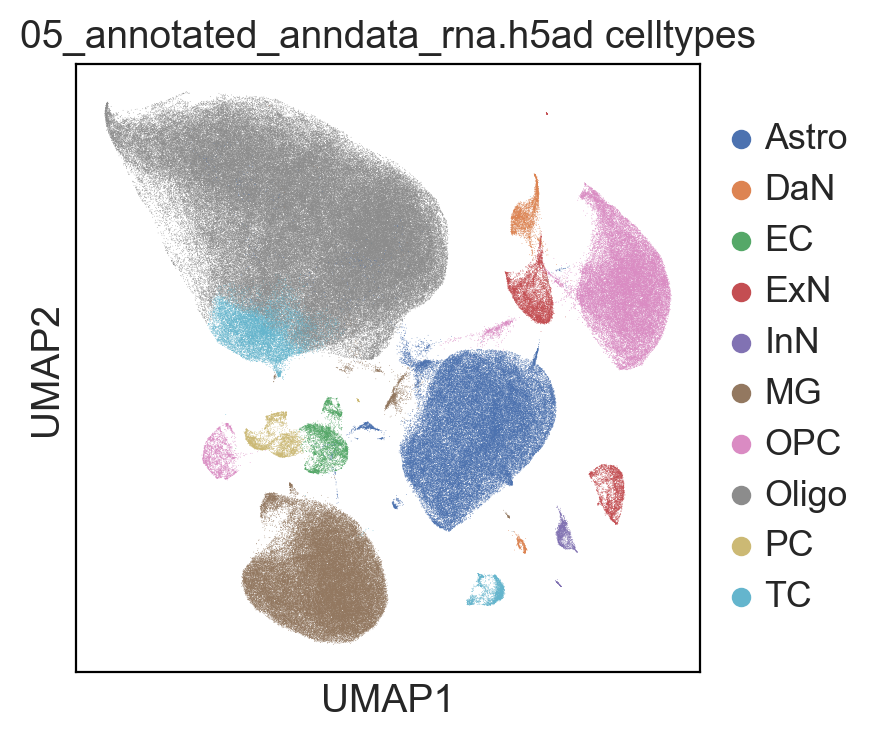

In [85]:
# PLOT - umap by cell type using scanpy
sc.pl.umap(
    adata,
    color   = 'cell_type',
    title   = f'{os.path.basename(input_file)} celltypes',
    # save    = output_path,
    )

In [68]:
1/0

ZeroDivisionError: division by zero

### FILTERED UMAPS

List of variables to plot:
```
- young VS old (binned)
- 'age' on a continuous spectrum
- 'pmi'
- filter out PC??? --> ask Adam
```

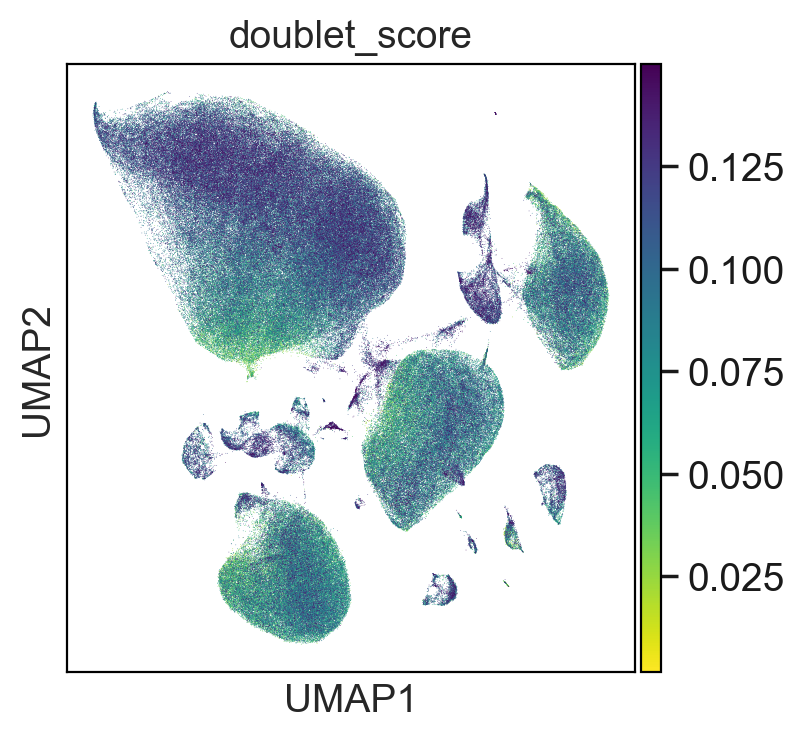

In [82]:
# PLOT - UMAP by PMI
sc.pl.umap(adata, color = 'doublet_score')

In [ ]:
# PLOT - UMAP by PMI
sc.pl.umap(adata, color = 'total_counts_rb')

In [ ]:
# PLOT - UMAP by PMI
sc.pl.umap(adata, color = 'total_counts_mt')

In [ ]:
1/0

In [ ]:
# Get PMI range
adata.obs['pmi'].describe()

In [ ]:
# PLOT - UMAP by PMI
sc.pl.umap(adata, color = 'pmi')

In [ ]:
# Get age range
adata.obs['age'].describe()

In [ ]:
# PLOT - UMAP by age
sc.pl.umap(adata, color='age')

In [ ]:
# CALCULATE - Age stats
print('Describe Age column = \n', df.describe()['Age'], '\n')

age_max = df.describe()['Age']['max']
print('age_max =', age_max)

age_min = df.describe()['Age']['min']
print('age_min =', age_min)

# Math
print(f'{age_max} - {age_min} = {age_max - age_min}')
print(f'{age_max - age_min} / 2 = {(age_max - age_min) / 2}')
print(f'{age_min} + {(age_max - age_min) / 2} = {age_min + (age_max - age_min) / 2}')

# NOTE - ok to use the 50% row
age_half = df.describe()['Age']['50%']
print('age_half =', age_half)

In [ ]:
# CHECK
adata.obs['age']

In [ ]:
# EXTRACT - Age col, split into young/old, unique vals only, convert to a list, 
age_old = df[df['Age'] >= age_half]['Age'].unique().tolist()
print('age_old =', age_old)
print('\n')
age_young = df[df['Age'] < age_half]['Age'].unique().tolist()
print('age_young =', age_young)

In [ ]:
# CREATE - new 'age_old' col, based on whether it's higher/lower than the age_half pt
adata.obs['age_old'] = adata.obs['age'] >= age_half
adata.obs['age_old']

In [ ]:
# PLOT - UMAP of old VS young ages
sc.pl.umap(
    adata, 
    color = 'age_old'
    )

In [ ]:
# EDIT - adata obj creating a new col called `age_bin' and the value depends on age being >= the halfway point
adata.obs['age_bin'] = np.where(
    adata.obs['age_old'], 
    f'old (>= {age_half})', 
    f'young (< {age_half})')
adata.obs['age_bin']

In [ ]:
# PLOT - Customize UMAP of old VS young ages
fig = sc.pl.umap(
    adata, 
    color = 'age_bin', 
    title = 'Control group ages: \nYoung VS Old',
    return_fig = True
    )
ax = fig.axes[0]
ax.legend_.set_title('Age (yrs)')

In [ ]:
# CHECK
adata.obs

In [ ]:
# CHECK
adata.obs['age_bin']

In [ ]:
# CHECK - count
adata.obs['age_bin'].value_counts()

In [ ]:
#! ERROR - this ain't right...

# PLOT - Age split by young/old

# Set Seaborn style
sns.set(style = 'whitegrid')

column_name = 'age_bin'

# # PLOT - histogram
# sns.histplot(df[column_name], bins = 2, kde = False)
# sns.histplot(adata.obs[column_name], bins = 2, kde = False)
sns.histplot(adata.obs[column_name], kde = False)

# ADD - title and labels
plt.title(f'{column_name} Distribution')
plt.xlabel(f'{column_name} (years)')
plt.ylabel('Frequency')

# SHOW - plot
plt.show()

In [ ]:
# Define a function to check for existing dir's and create them if missing
def my_makedirs(path):
    """
    Provide a full file path, this will grab just the parent directory and check if it exists, if not, it will create it.
    """
    # Get the parent directory path
    path = os.path.dirname(path)
    
    # If-else logic to check if they exist, if not, create the directory
    if not os.path.isdir(path):
        os.makedirs(path)
        print(f"Created: {path}")
    else:
        print(f"\'/{path}\' folder is already there")

# Define output file path for my testing, base on the original file name
output_file = os.path.join('output', os.path.basename(input_file).replace('.h5ad', '-ef.h5ad'))
print('output_file =', output_file)

# Call function to check for or create that path to the output file location
my_makedirs(output_file)

### QC

In [ ]:
# Mitochondrial genes "MT-" for human
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# Ribosomal genes
adata.var['ribo'] = adata.var_names.str.startswith (('RPS', 'PRL'))

In [ ]:
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars = ['mt', 'ribo'],
    inplace = True,
    log1p = True
)

In [ ]:
# PLOT - violin plot of QC metrics
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter = 0.4,
    multi_panel = True,
)

Useful to consider QC metrics jointly by inspecting a scatter plot colored by `pct_counts_mt`

In [ ]:
sc.pl.scatter(
    adata,
    'total_counts',
    'n_genes_by_counts',
    color = 'pct_counts_mt'
)

# FILTER??? - Check snakemake rules 1st

In [ ]:
# sc.pp.filter_cells(adata, min_genes = 100)

# #? Q) How to check this?

In [ ]:
# # CHECK - starting # of genes
# print(f'# of genes pre-filtering: {adata.n_vars}')

# # Remove genes detected in < 3 cells (along w/the 0 count genes)
# sc.pp.filter_genes(adata, min_cells = 3)

# # CHECK - remaining genes
# print(f'# of genes post-filtering: {adata.n_vars}')

### DIFFERENTIALLY-EXPRESSED (DE) GENES AS MARKERS

Can also calc marker genes/cluster and then look up whether we can link those marker genes to known biology (ie. cell types and/or states). Can be done using simple stat tests (ie. Wilcoxon and t-test) for each cluster VS the rest.

In [ ]:
# CHECK
adata

In [ ]:
# # CHECK - already done by Adam
# sc.pp.log1p(adata)

In [ ]:
#* NOTE - don't need the rank genes 

# #! WARNING - It seems you use rank_genes_groups on the raw count data. Please logarithmize your data before calling rank_genes_groups.
# #* NOTE - need to specify the layer as 'data' and `use_raw = False`
# #! WARNING - took 32 mins - ~3 hrs, might crash in sinteractive (run as sbatch.sh script then reload the adata obj afterwards)

# # Obtain cluster-specific DE genes
# sc.tl.rank_genes_groups(
#     adata, 
#     groupby = 'age_bin',
#     method  = 'wilcoxon',
#     layer   = 'data' ,      # ADAM: already normalized + logarithmized
#     use_raw = False,
# )

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SAVE + RELOAD

In [ ]:
# Define output file path for my testing, base on the original file name
output_file = os.path.join('output', os.path.basename(input_file).replace('.h5ad', '-ef-rank_genes_groups.h5ad'))
print('output_file =', output_file)

In [ ]:
# # Save the AnnData object
# adata.write_h5ad(
#     filename = output_file, 
#     compression = 'gzip'
#     )

In [ ]:
# RELOAD - my saved AnnData object
adata = sc.read_h5ad(output_file)
adata

In [ ]:
pprint.pprint(adata.uns)

In [ ]:
# EXTRACT - list of ranked genes (I think it's returning highest expression in BOTH old/young groups)
rank_genes_groups_names_array = adata.uns['rank_genes_groups']['names']
print('rank_genes_groups_names_array.shape =', rank_genes_groups_names_array.shape)
print('rank_genes_groups_names_array[:30] =', rank_genes_groups_names_array[:30])

In [ ]:
# CHECK - see the DF of the rank genes groups 
sc.get.rank_genes_groups_df(adata, group = None)

In [ ]:
# Log scaling of the palette
norm = mcolors.LogNorm()

In [ ]:
# # TEST - EXAMPLE - scaling the vmin/vmax

# # # Make mock col w/log-normally distributed values
# # adata.obs['lognormal'] = np.random.lognormal(3, 1, adata.shape[0])

# # PLOT - heatmap
# sc.pl.umap(
#     adata,
#     color = 'lognormal', 
#     s = 20,
#     norm = norm,
# )

# # #? Q) What does this part do?
# # #? A) Cleans up the 'lognormal' col it created and drops it
# # adata.obs.drop(
# #     'lognormal', 
# #     axis = 1,
# #     inplace = True
# #     )

# #* TODO - Vmin/Vmax - normalize axes based on the range in my dataset
# # - by separately plotting these to see

### #? Q) What is the score?

#? A) Wilcoxon test results

In [ ]:
# FILTER - young ranked gene groups
dc_cluster_genes_young = sc.get.rank_genes_groups_df(
    adata, 
    group = 'young (< 57.9)'
).head(5)['names']

# PLOT - heatmap of top 5 DE genes from the young group
sc.pl.umap(
    adata,
    color       = dc_cluster_genes_young,
    legend_loc  = 'on data',
    frameon     = True,
    ncols       = 3
)

#! WARNING - nearly all 0s

#* TODO - Vmin/Vmax - normalize axes based on the range in my dataset
# - by separately plotting these to see

In [ ]:
# FILTER - young group, just names
dc_cluster_genes_young = sc.get.rank_genes_groups_df(
    adata, 
    group = 'young (< 57.9)'
).head(5)['names']

dc_cluster_genes_young

In [ ]:
# Normalizing legend

# PLOT - heatmap of top 5 DE genes from the young group
sc.pl.umap(
    adata,
    color       = dc_cluster_genes_young,
    s           = 20,       # Size of points
    norm        = norm,     # Log normalization of color palette
    legend_loc  = 'on data',
    frameon     = True,
    ncols       = 3
)

In [ ]:
# FILTER - old group, just names
dc_cluster_genes_old = sc.get.rank_genes_groups_df(
    adata, 
    group = 'old (>= 57.9)'
).head(5)['names']

dc_cluster_genes_old

In [ ]:
# Normalizing legend

# PLOT - heatmap of top 5 DE genes from the old group
sc.pl.umap(
    adata,
    color       = dc_cluster_genes_old,
    s           = 20,       # Size of points
    norm        = norm,     # Log normalization of color palette
    legend_loc  = 'on data',
    frameon     = True,
    ncols       = 3,
)

In [ ]:
# TEST - scaling the vmin/vmax using quartiles?

# # IMPORTS
# from functools import partial

# PLOT - heatmap of top 5 DE genes from the young group
sc.pl.umap(
    adata,
    # color       = [dc_cluster_genes_young, dc_cluster_genes_old],     #! ERROR
    color       = dc_cluster_genes_young,
    legend_loc  = 'on data',
    frameon     = True,
    ncols       = 5,
    vmin        = 'p90',
    vmax        = 'p90',
)

#* TODO - Vmin/Vmax - normalize axes based on the range in my dataset
# - by separately plotting these to see

Where is the list of genes from ranking the genes coming from?

In [ ]:
adata.var

In [ ]:
adata.var_names[0:20]

# #* TODO

XYLENA: 
- pseudobulk each category (young/old) then run w/the tools Adam used
- avg's expression of each cell type in each sample
- should have a tool in scanpy
- also in Adam's pipeline

ADAM
- break up the adata obj into indiv clusters by cell type for the trajectory analysis
- redo the DGE by cell type, 
- use the leiden_2 cluster

Pseudo-bulking = collapsing into counts the mean expression for that sample
- sum is better for genes that are lowly expressed by highly variable betw samples
- mean is better for genes that are highly expressed genes

Lit review on pseudotime and trajectory analysis tools, run by some suggestions by Xylena before starting on one

# DGE

In [ ]:
# %pip install dash_bio

In [ ]:
# PVALS - why is it all 0's? 
sc.get.rank_genes_groups_df(adata, group = None).pvals

In [ ]:
# PVALS
adata.uns['rank_genes_groups']['pvals']

In [ ]:
# CHECK
import pprint

pprint.pprint(adata.uns['rank_genes_groups'])

In [ ]:
# LOG2FC
adata.uns['rank_genes_groups']['logfoldchanges']

print(type(adata.uns['rank_genes_groups']['logfoldchanges']))

In [ ]:
# # TEST
# volcano_df = pd.DataFrame({
#     # adata
#     # adata.uns
#     # adata.uns['rank_genes_groups']
#     # adata.uns['rank_genes_groups']['logfoldchanges']
# 	dataframe = sc.get.rank_genes_groups_df(adata, group = None)
# })

In [ ]:
sc.get.rank_genes_groups_df(adata, group = None)

In [ ]:
# EFFECT SIZE
sc.get.rank_genes_groups_df(adata, group = None)['logfoldchanges']

In [ ]:
# PVALS
sc.get.rank_genes_groups_df(adata, group = None)['pvals'].unique()[:30]

In [ ]:
sc.get.rank_genes_groups_df(adata, group = None)['names']

In [ ]:
# IMPORT
import dash_bio

# EXTRACT - DF from rank genes groups w/the required columns
volcano_df = pd.DataFrame({
	'EFFECTSIZE': sc.get.rank_genes_groups_df(adata, group = None)['logfoldchanges'],  # Replace with actual effect sizes (log2FC)
	'PVALUE'	: sc.get.rank_genes_groups_df(adata, group = None)['pvals'],
    'GENE'      : sc.get.rank_genes_groups_df(adata, group = None)['names'],  # Add gene names if available
})

# PLOT - volcano plot
dash_bio.VolcanoPlot(
    dataframe   =  volcano_df,
    effect_size = 'EFFECTSIZE',
    p           = 'PVALUE',
    title       = 'Volcano Plot',
    snp         = None,
    gene        = 'GENE',
    genomewideline_value = -np.log10(0.05),  # Example threshold for significance
)

ADAM - the volcano plot doesn't have pseudobulk or celltyping clusters so this prolly won't be usable coming from the rank_genes_groups command

#* TODO - delete that part

# FILTER + MAKE UMAPS AGAIN

- check 01 file, might need to rerun that and annotate to make those UMAPs
- 05 file is already filtered